# Saliency Plots

In [3]:
from dna_features_viewer import BiopythonTranslator, GraphicFeature, GraphicRecord
from dna_features_viewer.biotools import annotate_biopython_record
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob, os, yaml, sparse, itertools, subprocess, sys, pickle
import statsmodels.stats.api as sm

import Bio.SeqUtils
import Bio.Data
from Bio import SeqIO
from Bio.Seq import Seq

plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.titlepad'] = 10
import scipy.stats as st

# saliency_utils is in the utils_files directory
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "utils"))
from saliency_utils import *
from inSilicoMut_utils import *
from data_utils import *

from sklearn.linear_model import LinearRegression
BASE_TO_COLUMN = {'A': 0, 'C': 1, 'T': 2, 'G': 3, '-': 4}

results_path = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"
vcf_dir = "/n/scratch3/users/s/sak0914/annotated_VCF"

solo_results = pd.read_excel("/home/sak0914/who-analysis/data/SOLO primary_STATA_ver18Feb2023.xlsx", sheet_name="Sheet1")
who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")
who_variants_clean = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")
coll_2014 = pd.read_csv("/home/sak0914/who-analysis/data/coll2014_SNP_scheme.tsv", sep="\t")

df_mxf = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/data_for_model.csv")
df_mxf_val = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/validation_data_for_model.csv")

df_rif = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/data_for_model.csv")
df_rif_val = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/validation_data_for_model.csv")

h37Rv = SeqIO.read("/n/data1/hms/dbmi/farhat/Sanjana/GCF_000195955.2_ASM19595v2_genomic.gbff", "genbank")
h37Rv_genes = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/mycobrowser_h37rv_genes_v4.csv")

RIF_isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/rpoBC_variants_10543isolates.csv")
MXF_isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/gyrBA_variants_8569isolates.csv")

lineages = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineages.csv")
lineage_mat = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix_Coll2014.csv", index_col=[0])

# RIF_lineage_pred = pd.read_csv("../analysis/Rifampicin/insilico_mutagenesis/lineage_predictions.csv")
# MXF_lineage_pred = pd.read_csv("../analysis/Moxifloxacin/insilico_mutagenesis/lineage_predictions.csv")

In [1]:
import sparse

In [5]:
import numpy as np

In [6]:
scores = np.load("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_7Loci/saliency/quant/scores_max_full.npy")

In [7]:
scores.shape

(4832, 7)

In [9]:
np.max(scores)

0.23139085

In [10]:
np.min(scores)

0.0

# Rifampicin

1 loci!
Computing saliency significance with 10 max scores and 10 min scores
17 Cat 1 WHO catalog sites for RIF
1 Cat 1 WHO catalog sites not found
Sites not found: [761134]


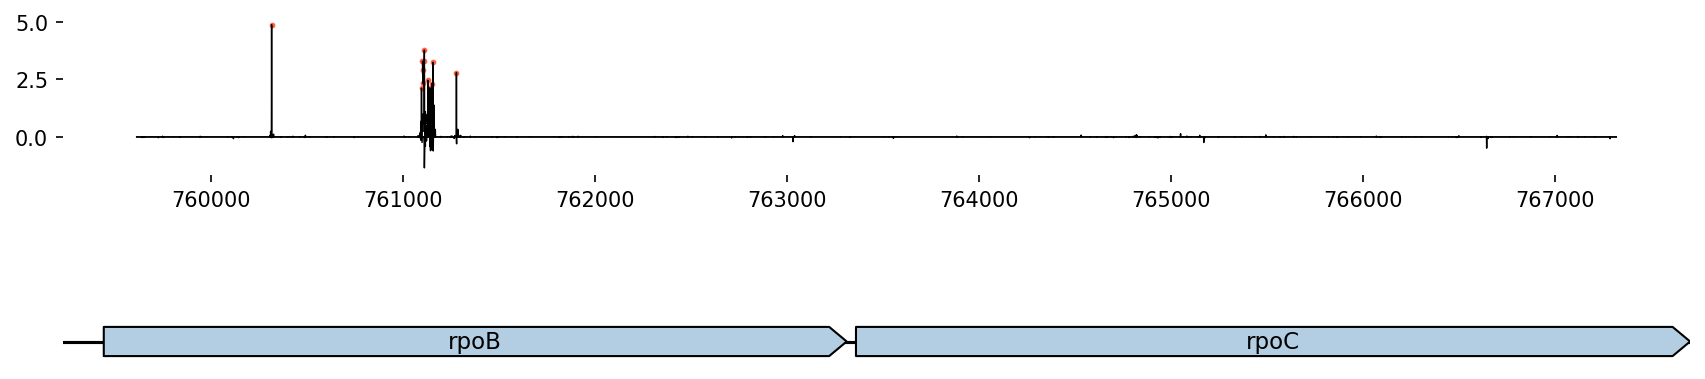

In [4]:
RIF_rpoBC_df, rpoBC_seqDict = generate_saliency_plots("RIF",
                                                      os.path.join(results_path, "RIF_rpoBC"),
                                                      ["rpoBC"],
                                                      plot_thresh=2,
                                                      cat_to_check=["1"],
                                                      binary=False,
                                                      save=True,
                                                      significance=True,
                                                      sig_thresh=0.05,
                                                     )


RIF_rpoBC_scores = sparse.load_npz(os.path.join(results_path, "RIF_rpoBC/saliency/quant/genetic_scores_unpooled_nuc.npy.npz")).todense()
# RIF_rpoBC_df.to_csv("../analysis/Rifampicin/rpoBC_saliency_results.csv", index=False)
# rpoBC_seqDict["rpoBC"].to_csv("/home/sak0914/MtbQuantCNN/analysis/Rifampicin/rpoBC_seqdf.csv")

In [5]:
RIF_rpoBC_df.query("Pos==761134")

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
1575,rpoBC,761134.0,0.0,0.0,0.0,0.0,1,0,0


In [16]:
len(RIF_rpoBC_df.query("WHO == 1"))

17

In [20]:
RIF_rpoBC_df.iloc[1520:1535]

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
1520,rpoBC,761091.0,0.000000,0.000000,0.0,0.0,0,0,0
1521,rpoBC,761092.0,0.561958,0.000000,1.0,0.0,0,0,0
1522,rpoBC,761093.0,0.684522,-0.151196,1.0,1.0,0,0,0
1523,rpoBC,761094.0,0.000000,0.000000,0.0,0.0,0,0,0
1524,rpoBC,761095.0,2.124501,0.000000,1.0,0.0,1,0,0
1525,rpoBC,761096.0,0.257387,0.000000,1.0,0.0,0,0,0
1526,rpoBC,761097.0,0.559906,0.000000,1.0,0.0,0,0,0
1527,rpoBC,rpoBC_40,0.523641,0.000000,1.0,0.0,0,0,0
1528,rpoBC,rpoBC_41,1.614241,0.000000,1.0,0.0,0,0,0
1529,rpoBC,rpoBC_42,1.209943,0.000000,1.0,0.0,0,0,0


In [26]:
pos_scores_only = RIF_rpoBC_df.loc[~RIF_rpoBC_df["Pos"].astype(str).str.contains("_")]
pos_scores_only["Pos"] = [int(float(val)) for val in pos_scores_only["Pos"].values]

In [80]:
#RIF_rpoBC_df.loc[RIF_rpoBC_df["Pos"].astype(str).str.contains("_")].query("Max_Sig == 1")

<Axes: xlabel='Max', ylabel='Count'>

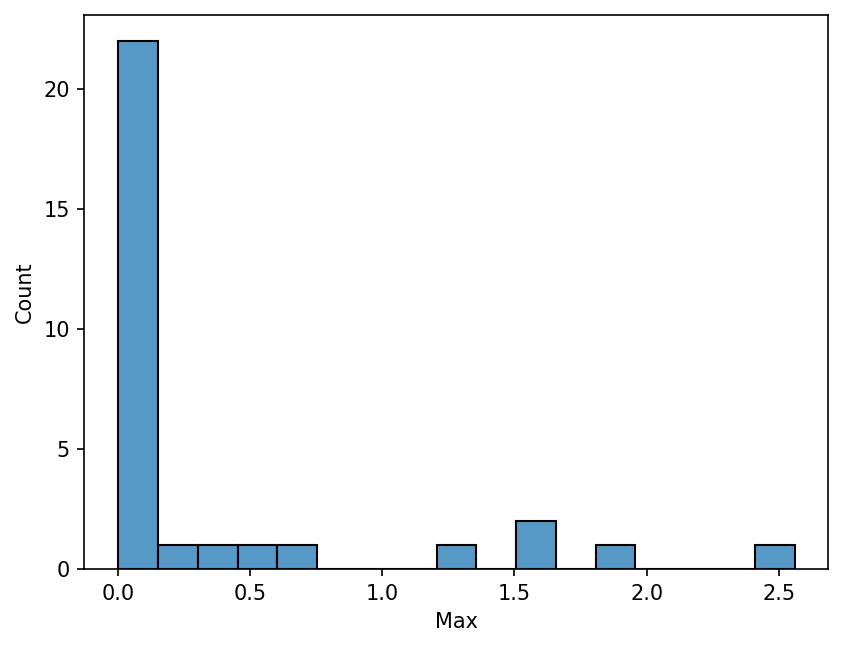

In [78]:
sns.histplot(RIF_rpoBC_df.loc[RIF_rpoBC_df["Pos"].astype(str).str.contains("_")].query("Max_Sig == 1")["Max"])

In [76]:
RIF_rpoBC_df.loc[RIF_rpoBC_df["Pos"].astype(str).str.contains("_")].query("Max_Sig == 1").sort_values("Max", ascending=False)

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
1538,rpoBC,rpoBC_46,2.559679,0.0,1.0,0.0,0,0,0
1539,rpoBC,rpoBC_47,1.875858,0.0,1.0,0.0,0,0,0
1528,rpoBC,rpoBC_41,1.614241,0.0,1.0,0.0,0,0,0
1545,rpoBC,rpoBC_49,1.508072,0.0,1.0,0.0,0,0,0
1529,rpoBC,rpoBC_42,1.209943,0.0,1.0,0.0,0,0,0
1546,rpoBC,rpoBC_50,0.617216,0.0,1.0,0.0,0,0,0
1527,rpoBC,rpoBC_40,0.523641,0.0,1.0,0.0,0,0,0
1547,rpoBC,rpoBC_51,0.302710,0.0,1.0,0.0,0,0,0
1540,rpoBC,rpoBC_48,0.196359,0.0,1.0,0.0,0,0,0
2260,rpoBC,rpoBC_57,0.013636,0.0,1.0,0.0,0,0,0


In [115]:
idx = 39-1
RIF_rpoBC_df.iloc[idx:idx+10]

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
38,rpoBC,759648.0,0.000000,-0.012555,0.0,1.0,0,0,0
39,rpoBC,rpoBC_1,0.000000,-0.005192,0.0,1.0,0,0,0
40,rpoBC,rpoBC_2,0.000000,-0.006137,0.0,1.0,0,0,0
41,rpoBC,rpoBC_3,0.002536,0.000000,1.0,0.0,0,0,0
42,rpoBC,rpoBC_4,0.000993,0.000000,1.0,0.0,0,0,0
43,rpoBC,rpoBC_5,0.008125,0.000000,1.0,0.0,0,0,0
44,rpoBC,rpoBC_6,0.000000,-0.001741,0.0,0.0,0,0,0
45,rpoBC,rpoBC_7,0.000000,-0.009270,0.0,1.0,0,0,0
46,rpoBC,rpoBC_8,0.000000,-0.011318,0.0,1.0,0,0,0
47,rpoBC,rpoBC_9,0.000000,-0.007500,0.0,1.0,0,0,0


In [66]:
# sns.histplot(RIF_rpoBC_df.query("Max_Sig == 1 & Max > 0.1")["Max"])

In [113]:
who_variants_clean.query("genome_index.str.contains('|'.join(['759650']))").sort_values("genome_index")

,drug,genome_index,confidence,mutation


In [59]:
who_variants_clean.query("genome_index.str.contains('|'.join(['761097', '761102', '761106']))").sort_values("genome_index")

,drug,genome_index,confidence,mutation
370,RIF,761097,2) Assoc w R - Interim,rpoB_p.Ser431Gly
412,RIF,761097,2) Assoc w R - Interim,rpoB_p.Ser431Arg
506,RIF,761097,2) Assoc w R - Interim,rpoB_p.Gln432_Met434del
401,RIF,"761100,761102",2) Assoc w R - Interim,rpoB_p.Gln432Asn
50,RIF,761102,1) Assoc w R,rpoB_p.Phe433dup
386,RIF,761102,2) Assoc w R - Interim,rpoB_p.Gln432His
314,RIF,761106,2) Assoc w R - Interim,rpoB_p.Met434Leu
380,RIF,761106,2) Assoc w R - Interim,rpoB_p.Met434Val
420,RIF,761106,2) Assoc w R - Interim,rpoB_p.Met434_Asn437delinsIle


# Indels with High Positive Scores

In [120]:
RIF_isolate_variants.query("Isolate=='ERR4828591'")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation,RIF_midpoint,category,new_variant
13667,759627.0,A,ACTTGACACCGTGGTCTTAGTC,PASS,0.46,mazF2,upstream_gene_variant,c.-4635_-4634insGACTAAGACCACGGTGTCAAG,.,ERR4828591,mazF2_c.-4635_-4634insGACTAAGACCACGGTGTCAAG,0.03,train,c.-4635_-4634insGACTAAGACCACGGTGTCAAG
13668,759648.0,C,CCTTGACACCGTGGTCTTAGTC,PASS,0.76,mazF2,upstream_gene_variant,c.-4656_-4655insGACTAAGACCACGGTGTCAAG,.,ERR4828591,mazF2_c.-4656_-4655insGACTAAGACCACGGTGTCAAG,0.03,train,c.-4656_-4655insGACTAAGACCACGGTGTCAAG
13669,763031.0,T,C,PASS,1.00,rpoB,synonymous_variant,c.3225T>C,p.Ala1075Ala,ERR4828591,rpoB_c.3225T>C,0.03,train,c.3225T>C


In [123]:
df_rif.query("ROLLINGDB_ID=='ERR4828591'")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ID,ISOLATION_LOCATION,DB_OF_ORIGIN,STUDY_NAME,STUDY_PMID,TESTING_LOCATION,MEDIA,RIF,RIF_lower_bound,RIF_midpoint,RIF_upper_bound,RIF_quality,Path,Coll2014,Binary,Lineage,category
6801,ERR4828591,ERS5317664,site.08.subj.24TB00-047.lab.2433.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,<=0.06,0.0,0.03,0.06,HIGH,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,2.2.1,0,2,original_train_set


In [119]:
RIF_isolate_variants.query("POS==759648")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation,RIF_midpoint,category,new_variant
4052,759648.0,C,T,PASS,1.00,mazF2,upstream_gene_variant,c.-4655G>A,.,ERR3287654,mazF2_c.-4655G>A,0.03,train,c.-4655G>A
9492,759648.0,C,CT,PASS,1.01,mazF2,upstream_gene_variant,c.-4656_-4655insA,.,ERR4810667,mazF2_c.-4656_-4655insA,0.03,train,c.-4656_-4655insA
13668,759648.0,C,CCTTGACACCGTGGTCTTAGTC,PASS,0.76,mazF2,upstream_gene_variant,c.-4656_-4655insGACTAAGACCACGGTGTCAAG,.,ERR4828591,mazF2_c.-4656_-4655insGACTAAGACCACGGTGTCAAG,0.03,train,c.-4656_-4655insGACTAAGACCACGGTGTCAAG


In [118]:
RIF_isolate_variants.query("POS in [761097, 761102, 761106, 761813]").drop_duplicates("mutation").sort_values("POS")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation,RIF_midpoint,category,new_variant
3143,761097.0,A,AGCC,PASS,0.98,rpoB,disruptive_inframe_insertion,c.1292_1294dupGCC,p.Ser431_Gln432insArg,ERR2510627,rpoB_p.Ser431_Gln432insArg,4.000,test,p.Ser431_Gln432insArg
17844,761097.0,A,G,PASS,1.00,rpoB,missense_variant,c.1291A>G,p.Ser431Gly,ERR4831654,rpoB_p.Ser431Gly,8.000,train,p.Ser431Gly
23220,761097.0,A,C,Amb,0.27,rpoB,missense_variant,c.1291A>C,p.Ser431Arg,SAMN02360565,rpoB_p.Ser431Arg,16.000,train,p.Ser431Arg
1162,761102.0,A,ATTC,PASS,0.93,rpoB,conservative_inframe_insertion,c.1297_1299dupTTC,p.Phe433dup,C447,rpoB_p.Phe433dup,6.000,validation,p.Phe433dup
2803,761102.0,A,T,PASS,1.00,rpoB,missense_variant,c.1296A>T,p.Gln432His,ERR2510525,rpoB_p.Gln432His,3.000,train,p.Gln432His
8001,761102.0,ATTCATGGAC,A,PASS,1.00,rpoB,conservative_inframe_deletion,c.1297_1305delTTCATGGAC,p.Phe433_Asp435del,ERR4797676,rpoB_p.Phe433_Asp435del,4.000,train,p.Phe433_Asp435del
19534,761106.0,A,C,PASS,1.00,rpoB,missense_variant,c.1300A>C,p.Met434Leu,JPN-R2012-0083,rpoB_p.Met434Leu,0.375,validation,p.Met434Leu
19800,761106.0,A,G,PASS,1.00,rpoB,missense_variant,c.1300A>G,p.Met434Val,KOR-K2016-0113,rpoB_p.Met434Val,28.000,validation,p.Met434Val
20376,761106.0,A,ATGG,PASS,0.97,rpoB,disruptive_inframe_insertion,c.1301_1303dupTGG,p.Met434_Asp435insVal,NLA009600800,rpoB_p.Met434_Asp435insVal,5.000,train,p.Met434_Asp435insVal
23022,761106.0,ATGG,A,PASS,0.71,rpoB,disruptive_inframe_deletion,c.1301_1303delTGG,p.Met434_Asp435delinsAsn,RB00104514,rpoB_p.Met434_Asp435delinsAsn,12.000,validation,p.Met434_Asp435delinsAsn


In [102]:
pos = 761106
idx = RIF_rpoBC_df.query("Pos==@pos").index.values[0] 
print(f"Ref: {rpoBC_seqDict['rpoBC'].loc['MT_H37Rv', pos]}")
max_scores = np.max(RIF_rpoBC_scores[:, :, idx, 0], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), max_scores))

Ref: A


{'A': 0.0, 'C': 0.0, 'T': 0.0, 'G': 0.0, '-': 0.903983}

'A'

In [87]:
RIF_rpoBC_scores.shape

(7310, 5, 7826, 1)

In [34]:
pos_scores_only.query("WHO == 0 & (Max_Sig == 1) & ~(Pos >= 761082 & Pos <= 761162) & Max > 0.1").sort_values("Max", ascending=False).Pos.values

array([761284, 761167, 760309, 761279, 761164, 765050, 760324])

In [36]:
search_lst = np.array([761284, 761167, 760309, 761279, 761164, 765050, 760324]).astype(str)

In [42]:
np.sort(search_lst.astype(int))

array([760309, 760324, 761164, 761167, 761279, 761284, 765050])

In [43]:
who_variants_clean.query("genome_index.str.contains('|'.join(@search_lst))").sort_values("genome_index")

,drug,genome_index,confidence,mutation
4619,RIF,760309,3) Uncertain significance,rpoB_p.Val168Ala
4923,RIF,760309,3) Uncertain significance,rpoB_p.Val168Gly
4993,RIF,760324,3) Uncertain significance,rpoB_p.Leu173Pro
4987,RIF,761164,3) Uncertain significance,rpoB_p.Gly453Ala
4831,RIF,761167,3) Uncertain significance,rpoB_p.Pro454Arg
4968,RIF,761167,3) Uncertain significance,rpoB_p.Pro454His
5600,RIF,761167,3) Uncertain significance,rpoB_p.Pro454Leu
4620,RIF,761279,3) Uncertain significance,rpoB_p.Ile491Met
4688,RIF,761284,3) Uncertain significance,rpoB_p.Ser493Leu
5540,RIF,761284,3) Uncertain significance,rpoB_p.Ser493Trp


In [19]:
RIF_rpoBC_df.query("WHO == 0 & (Max_Sig == 1 | Min_Sig == 1) & Pos").sort_values("Max", ascending=False).head(20)

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
1538,rpoBC,rpoBC_46,2.559679,0.000000,1.0,0.0,0,0,0
1590,rpoBC,761149.0,2.323448,0.000000,1.0,0.0,0,0,0
1539,rpoBC,rpoBC_47,1.875858,0.000000,1.0,0.0,0,0,0
1528,rpoBC,rpoBC_41,1.614241,0.000000,1.0,0.0,0,0,0
1545,rpoBC,rpoBC_49,1.508072,0.000000,1.0,0.0,0,0,0
1589,rpoBC,761148.0,1.503381,0.000000,1.0,0.0,0,0,0
1582,rpoBC,761141.0,1.317395,0.000000,1.0,0.0,0,0,0
1529,rpoBC,rpoBC_42,1.209943,0.000000,1.0,0.0,0,0,0
1578,rpoBC,761137.0,1.105381,0.000000,1.0,0.0,0,0,0
1556,rpoBC,761115.0,1.103690,-0.405546,1.0,1.0,0,0,0


In [6]:
who_variants_clean = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")
who_variants_clean.query("drug=='RIF' & confidence=='1) Assoc w R' & genome_index.str.contains('761134')")

,drug,genome_index,confidence,mutation
58,RIF,761134,1) Assoc w R,rpoB_p.Thr444dup


In [12]:
rpoBC_seqDict["rpoBC"][761134].unique()

array(['T'], dtype=object)

In [13]:
rpoBC_seqDict["rpoBC"].shape

(9138, 7826)

In [6]:
print(RIF_rpoBC_df.query("Max > 0 | Min < 0").shape)
print(RIF_rpoBC_df.query("(Max_Sig == 1 & Max > 0) | (Min_Sig == 1 & Min < 0)").shape)

(772, 9)
(614, 9)


1 loci!
Computing saliency significance with 10 max scores and 10 min scores
17 Cat 1 WHO catalog sites for RIF
1 Cat 1 WHO catalog sites not found
Sites not found: [761134]


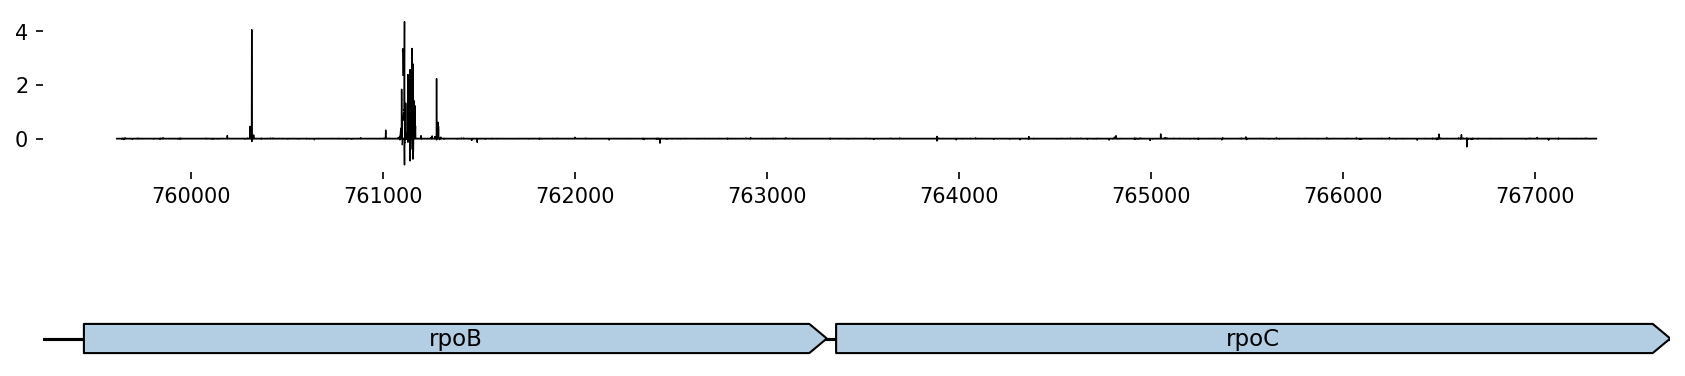

In [182]:
RIF_rpoBC_lineage_df, _ = generate_saliency_plots("RIF",
                                                      os.path.join(results_path, "RIF_rpoBC_lineage"),
                                                      ["rpoBC"],
                                                      plot_thresh=10,
                                                      cat_to_check=["1"],
                                                      binary=False,
                                                      save=True,
                                                      significance=True,
                                                      sig_thresh=0.05,
                                                     )

In [8]:
print(RIF_rpoBC_lineage_df.query("Max > 0 | Min < 0").shape)
print(RIF_rpoBC_lineage_df.query("(Max_Sig == 1 & Max > 0) | (Min_Sig == 1 & Min < 0)").shape)

(772, 9)
(626, 9)


In [2]:
# RIF_rpoBC_binary_df, _ = generate_saliency_plots("RIF",
#                                                  os.path.join(results_path, "RIF_rpoBC"),
#                                                  ["rpoBC"],
#                                                  plot_thresh=20,
#                                                  cat_to_check=["1"],
#                                                  binary=True,
#                                                  save=True,
#                                                  significance=True,
#                                                  sig_thresh=0.05,
#                                                 )

In [10]:
print(RIF_rpoBC_binary_df.query("Max > 0 | Min < 0").shape)
print(RIF_rpoBC_binary_df.query("(Max_Sig == 1 & Max > 0) | (Min_Sig == 1 & Min < 0)").shape)

(772, 9)
(722, 9)


In [11]:
set(RIF_rpoBC_df.query("Max > 0 | Min < 0")["Pos"]).symmetric_difference(RIF_rpoBC_binary_df.query("Max > 0 | Min < 0")["Pos"])

set()

In [152]:
max_thresh = RIF_rpoBC_df.query("Max != 0").Max.mean()
min_thresh = RIF_rpoBC_df.query("Min != 0").Min.mean()
RIF_rpoBC_df.query("(Max_Sig == 1 & Max > @max_thresh) | (Min_Sig == 1 & Min < @min_thresh)").shape

(86, 9)

In [151]:
max_thresh = RIF_rpoBC_binary_df.query("Max != 0").Max.mean()
min_thresh = RIF_rpoBC_binary_df.query("Min != 0").Min.mean()
RIF_rpoBC_binary_df.query("(Max_Sig == 1 & Max > @max_thresh) | (Min_Sig == 1 & Min < @min_thresh)").shape

(83, 9)

(83, 9)

In [144]:
RIF_rpoBC_df.query("Max_Sig == 1 & Max > 0").shape

(281, 9)

In [143]:
RIF_rpoBC_binary_df.query("Max_Sig == 1 & Max > 0").shape

(424, 9)

In [23]:
RIF_rpoBC_scores.shape

(7310, 5, 7826, 1)

In [34]:
scores_761154 = pd.DataFrame(RIF_rpoBC_scores[:, :, 1595, 0])
scores_761154.columns = BASE_TO_COLUMN.keys()
scores_761154.index = df_rif.query("category=='original_train_set'")["ROLLINGDB_ID"].values

In [44]:
search_isolates = scores_761154.loc[(scores_761154["A"] < 0) | (scores_761154["G"] < 0)].index.values
scores_761154.loc[(scores_761154["A"] < 0) | (scores_761154["G"] < 0)]

,A,C,T,G,-
ERR4811111,0.000000,0.0,0.0,-0.369253,0.0
ERR4813066,-0.329211,0.0,0.0,0.000000,0.0
ERR4832006,0.000000,0.0,0.0,-0.354903,0.0
Peru4021,-0.329211,0.0,0.0,0.000000,0.0
Peru4103,-0.329211,0.0,0.0,0.000000,0.0
Peru4464,-0.329211,0.0,0.0,0.000000,0.0


In [135]:
def get_codon(search_isolates, codon_start):
    
    ref_codon = Bio.SeqUtils.IUPACData.protein_letters_1to3[h37Rv.seq[codon_start-1:codon_start+2].translate()]
    
    for sample_id in search_isolates:

        vcf_reader = vcf.Reader(filename=f"/n/scratch3/users/s/sak0914/annotated_VCF/{sample_id}.eff.vcf")

        found_records = []
        new_codon = list(h37Rv.seq[codon_start-1:codon_start+2])
        for record in vcf_reader:
            if record.POS >= codon_start and record.POS <= codon_start+2:
                found_records.append(record)

        for record in found_records:
            if record.POS == codon_start:
                new_codon[0] = str(record.ALT[0])
            elif record.POS == codon_start+1:
                new_codon[1] = str(record.ALT[0])
            elif record.POS == codon_start+2:
                new_codon[2] = str(record.ALT[0])
          
        aa = Bio.SeqUtils.IUPACData.protein_letters_1to3[Seq("".join(new_codon)).translate()]
        
        print(sample_id, aa)

In [136]:
get_codon(search_isolates, 761154)

ERR4811111 Val
ERR4813066 Met
ERR4832006 Val
Peru4021 Met
Peru4103 Met
Peru4464 Met


In [137]:
df_rif.query("ROLLINGDB_ID in @search_isolates")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ID,ISOLATION_LOCATION,DB_OF_ORIGIN,STUDY_NAME,STUDY_PMID,TESTING_LOCATION,MEDIA,RIF,RIF_lower_bound,RIF_midpoint,RIF_upper_bound,RIF_quality,Path,Coll2014,Binary,Lineage,category
309,ERR4811111,ERS5300829,site.02.subj.0395.lab.235084-15.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,>4.0,4.00,4.000,50000.0,HIGH,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,2.2.1,1,2,original_train_set
3279,ERR4813066,ERS5303226,site.05.subj.LR-2335.lab.FN-01418-18.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,>8.0,8.00,8.000,50000.0,HIGH,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,4.1.2.1,1,4,original_train_set
6143,ERR4832006,ERS5320953,site.08.subj.02TB2023.lab.21665.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,2.0,1.00,1.500,2.0,HIGH,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,2.2.1,1,2,original_train_set
8238,Peru4021,SAMN05918537,Peru4021,Peru,farhat_internal,NaN,NaN,NJH,m7h10,0.25-0.5,0.25,0.375,0.5,HIGH,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,4.1.2.1,0,4,original_train_set
8308,Peru4103,SAMN05919623,Peru4103,Peru,farhat_internal,NaN,NaN,NJH,m7h10,>50,50.00,50.000,50000.0,HIGH,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,4.1.2.1,1,4,original_train_set
8383,Peru4464,SAMN05918578,Peru4464,Peru,farhat_internal,NaN,NaN,NJH,m7h10,>50,50.00,50.000,50000.0,HIGH,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,4.1.2.1,1,4,original_train_set


In [ ]:
RIF_df.query("ROLLINGDB_ID in ['ERR4810944', 'ERR4810996', 'ERR4822586', 'ERR4796402']")

In [ ]:
get_codon_aa_change("RIF", RIF_df,)

In [78]:
INH_paths = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/INH/paths.txt", sep="\t", header=None)

In [83]:
isolate = "ERR4831303"
print(f"{INH_paths.loc[INH_paths[0].str.contains(isolate)].index.values[0]}/{len(INH_paths)}")

1384/9965


In [43]:
df_rif.query("ROLLINGDB_ID in @search_isolates")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ID,ISOLATION_LOCATION,DB_OF_ORIGIN,STUDY_NAME,STUDY_PMID,TESTING_LOCATION,MEDIA,RIF,RIF_lower_bound,RIF_midpoint,RIF_upper_bound,RIF_quality,Path,Coll2014,Binary,Lineage,category
309,ERR4811111,ERS5300829,site.02.subj.0395.lab.235084-15.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,>4.0,4.00,4.000,50000.0,HIGH,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,2.2.1,1,2,original_train_set
3279,ERR4813066,ERS5303226,site.05.subj.LR-2335.lab.FN-01418-18.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,>8.0,8.00,8.000,50000.0,HIGH,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,4.1.2.1,1,4,original_train_set
6143,ERR4832006,ERS5320953,site.08.subj.02TB2023.lab.21665.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,2.0,1.00,1.500,2.0,HIGH,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,2.2.1,1,2,original_train_set
8238,Peru4021,SAMN05918537,Peru4021,Peru,farhat_internal,NaN,NaN,NJH,m7h10,0.25-0.5,0.25,0.375,0.5,HIGH,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,4.1.2.1,0,4,original_train_set
8308,Peru4103,SAMN05919623,Peru4103,Peru,farhat_internal,NaN,NaN,NJH,m7h10,>50,50.00,50.000,50000.0,HIGH,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,4.1.2.1,1,4,original_train_set
8383,Peru4464,SAMN05918578,Peru4464,Peru,farhat_internal,NaN,NaN,NJH,m7h10,>50,50.00,50.000,50000.0,HIGH,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,4.1.2.1,1,4,original_train_set


In [ ]:
bcftools filter -i "POS == 761154" Peru4464.eff.vcf

In [21]:
RIF_rpoBC_df.query('Pos in [761127, 761134, 761154]')

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
1568,rpoBC,761127.0,0.295134,0.000000,1.0,0.0,1,0,0
1575,rpoBC,761134.0,0.000000,0.000000,0.0,0.0,1,0,0
1595,rpoBC,761154.0,0.718683,-0.369253,1.0,1.0,1,0,0


In [20]:
RIF_rpoBC_binary_df.query('Pos in [761127, 761134, 761154]')

,Gene,Pos,Max,Min,WHO,Coll_2014,Freschi_2020
1568,rpoBC,761127.0,0.0,-0.763407,1,0,0
1575,rpoBC,761134.0,0.0,0.000000,1,0,0
1595,rpoBC,761154.0,0.0,-0.720598,1,0,0


In [10]:
RIF_rpoBC_df.sort_values("Max", ascending=False)

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
731,rpoBC,760314.0,4.885251,0.000000,1.0,0.0,1,0,0
1551,rpoBC,761110.0,3.777351,-1.344943,1.0,1.0,1,0,0
1550,rpoBC,761109.0,3.310671,-0.310521,1.0,1.0,1,0,0
1535,rpoBC,761100.0,3.285572,0.000000,1.0,0.0,1,0,0
1596,rpoBC,761155.0,3.244264,0.000000,1.0,0.0,1,0,0
...,...,...,...,...,...,...,...,...,...
2720,rpoBC,762273.0,0.000000,0.000000,0.0,0.0,0,0,0
2719,rpoBC,762272.0,0.000000,0.000000,0.0,0.0,0,0,0
2718,rpoBC,762271.0,0.000000,0.000000,0.0,0.0,0,0,0
2717,rpoBC,762270.0,0.000000,0.000000,0.0,0.0,0,0,0


In [17]:
set(RIF_rpoBC_binary_df.query("Max > 0 | Min < 0").Pos).symmetric_difference(RIF_rpoBC_df.query("Max > 0 | Min < 0").Pos)

set()

In [ ]:
def get_scores_by_nuc(pos, seq_df, scores_matrix):
    
    search_idx = list(seq_df.columns).index(pos)#rif_rpoBC_lineage_df.query("Pos==@pos").index.values[0]
    ref = seq_df.loc["MT_H37Rv", pos]
    print(ref)
    
    return dict(zip(BASE_TO_COLUMN.keys(), np.max(scores_matrix[:, :, search_idx, 0], axis=0))), dict(zip(BASE_TO_COLUMN.keys(), np.min(scores_matrix[:, :, search_idx, 0], axis=0)))

# Are there Different Alleles with Different Scores at Sites where both Max and Min are Significant

In [ ]:
RIF_max_min_significant = rif_rpoBC_df.query("(Max > 0 & Max_Sig==1) & (Min < 0 & Min_Sig==1)")

In [ ]:
pos = 761154
get_scores_by_nuc(pos, rpoBC_seqdf, rif_rpoBC_scores)

T


({'A': 0.0, 'C': 0.6363485, 'T': 0.57845545, 'G': 0.40106404, '-': 0.0},
 {'A': -0.5066079, 'C': 0.0, 'T': -1.47051, 'G': -0.79187685, '-': 0.0})

In [ ]:
sum(get_scores_by_nuc(pos, rpoBC_seqdf, rif_rpoBC_scores)[1].values())

T


-2.7689947485923767

In [ ]:
rpoBC_seqdf[pos].value_counts()

C    9119
T      13
G       3
N       2
A       1
Name: 759940.0, dtype: int64

In [ ]:
who_variants.query("genome_index.str.contains('761154')")

,drug,genome_index,confidence,mutation
66,RIF,"761154,761155",1) Assoc w R,rpoB_p.Ser450Leu
377,RIF,"761154,761155",2) Assoc w R - Interim,rpoB_p.Ser450Met
390,RIF,"761154,761155",2) Assoc w R - Interim,rpoB_p.Ser450Gly
400,RIF,"761154,761155",2) Assoc w R - Interim,rpoB_p.Ser450Gln
443,RIF,"761154,761155",2) Assoc w R - Interim,rpoB_p.Ser450Val


# Moxifloxacin

In [3]:
os.path.join(results_path, "MXF_gyrBA")

'/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_gyrBA'

1 loci!
Computing saliency significance with 10 max scores and 10 min scores
6 Cat 1 WHO catalog sites for MXF
CNN found all Cat 1 WHO catalog sites for MXF


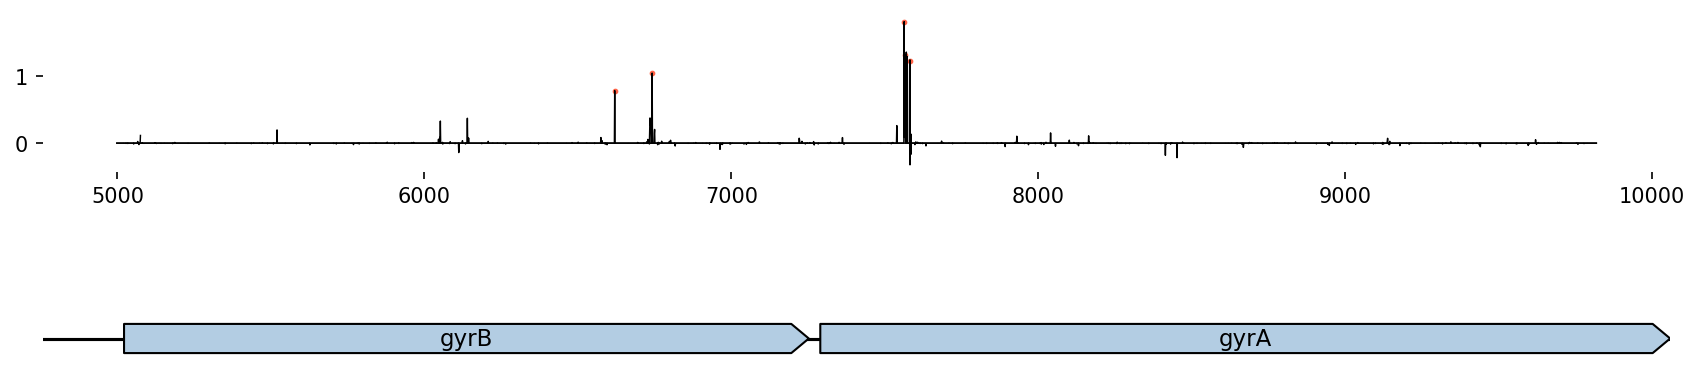

In [6]:
MXF_gyrBA_df, gyrBA_seqDict = generate_saliency_plots("MXF",
                                                      os.path.join(results_path, "MXF_gyrBA"),
                                                      ["gyrBA"],
                                                      plot_thresh=0.5,
                                                      cat_to_check=["1"],
                                                      binary=False,
                                                      save=True,
                                                      significance=True,
                                                      sig_thresh=0.05
                                                     )

# MXF_gyrBA_df.to_csv("/home/sak0914/MtbQuantCNN/analysis/Moxifloxacin/gyrBA_saliency_results.csv", index=False)
# gyrBA_seqDict["gyrBA"].to_csv("/home/sak0914/MtbQuantCNN/analysis/Moxifloxacin/gyrBA_seqdf.csv")

In [7]:
print(MXF_gyrBA_df.query("Max > 0 | Min < 0").shape)
print(MXF_gyrBA_df.query("(Max_Sig == 1 & Max > 0) | (Min_Sig == 1 & Min < 0)").shape)

(490, 9)
(341, 9)


1 loci!
Computing saliency significance with 10 max scores and 10 min scores
6 Cat 1 WHO catalog sites for MXF
CNN found all Cat 1 WHO catalog sites for MXF


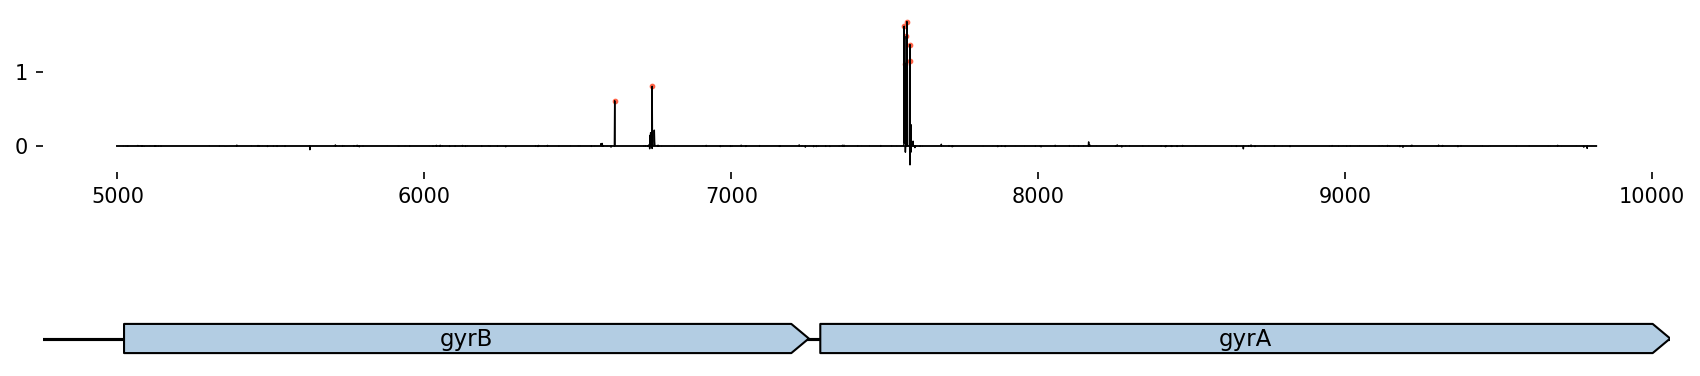

In [3]:
MXF_gyrBA_lineage_df, _ = generate_saliency_plots("MXF",
                                                  os.path.join(results_path, "MXF_gyrBA_lineage"),
                                                  ["gyrBA"],
                                                  plot_thresh=0.5,
                                                  cat_to_check=["1"],
                                                  binary=False,
                                                  save=True,
                                                  significance=True
                                                 )

In [4]:
os.path.join(results_path, "MXF_gyrBA_lineage")

'/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_gyrBA_lineage'

In [5]:
print(MXF_gyrBA_lineage_df.query("Max > 0 | Min < 0").shape)
print(MXF_gyrBA_lineage_df.query("(Max_Sig == 1 & Max > 0) | (Min_Sig == 1 & Min < 0)").shape)

(490, 9)
(216, 9)


In [22]:
100/300

0.3333333333333333

In [21]:
14/600

0.023333333333333334

In [ ]:
MXF_gyrBA_lineage_df.query("Pos==6734")

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
1744,gyrBA,6734.0,0.0,-0.037301,0.0,1.0,1,0,0


# Lineage Saliency Plots

In [157]:
def generate_lineage_saliency_plot(drug, drug_abbr, out_dir, df_phenos, binary_thresh, sig_thresh=0.2, significance=True, binary=False, savefName=None):
    
    df_phenos["log2-MIC"] = np.log2(df_phenos[f"{drug_abbr}_midpoint"])
    mean_log_mic = np.mean(df_phenos["log2-MIC"])
    print(f"Mean MIC: {df_phenos[f'{drug_abbr}_midpoint'].mean()}, Mean log2-MIC: {mean_log_mic}")
    
    
    ################################### STEP 1: MAKE LINEAGE MATRIX ###################################
    
    
    lineages = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix_Coll2014.csv", index_col=[0])
    lineages.columns = lineages.columns.astype(int)
    assert len(np.unique(lineages.values)) == 2

    # get only the training or testing set and subset the lineage matrix too
    lineages = lineages.loc[df_phenos["ROLLINGDB_ID"]]
    
    if binary:
        saliency_dir = os.path.join(out_dir, "saliency/binary")
    else:
        saliency_dir = os.path.join(out_dir, "saliency/quant")
        
    # get lineage scores for the primary model
    lineage_scores = np.load(os.path.join(saliency_dir, "lineage_scores.npy"))
    
    # create a dataframe with lineages, scores, and average log-MIC of isolates
    lineage_scores_df = pd.DataFrame({"position": lineages.columns, 
                                      "Max": lineage_scores.max(axis=0), 
                                      "Min": lineage_scores.min(axis=0)
                                     })
    
    lineage_scores_df = lineage_scores_df.merge(coll_2014[["#lineage", "position"]], on="position")
    lineage_scores_df.rename(columns={"#lineage":"Lineage"}, inplace=True)
    lineage_scores_df["Lineage"] = [val.replace("lineage", "") for val in lineage_scores_df["Lineage"].values]
    
    
    ################################### STEP 2: COMPUTE AVERAGE MIC OF EACH LINEAGE DIVIDED BY AVERAGE OF THE WHOLE DATASET ###################################
    
    
    # add log2-MIC to get averaged per lineage later
    lineages = lineages.merge(df_phenos[["ROLLINGDB_ID", "log2-MIC"]].set_index("ROLLINGDB_ID"), left_index=True, right_index=True)

    insilico_lineage_predictions = pd.read_csv(f"../analysis/{drug}/insilico_mutagenesis/lineage_predictions.csv")
    lineage_scores_df = lineage_scores_df.merge(insilico_lineage_predictions, on="Lineage", how="inner")

    for i, row in lineage_scores_df.iterrows():

        # add average log2-MIC of isolates with that SNP
        log2_MIC = lineages.loc[lineages[row["position"]]==1]["log2-MIC"].mean()
        lineage_scores_df.loc[i, ["log2-MIC", "MIC"]] = [log2_MIC, np.exp2(log2_MIC)]
    
        # then perform a hypothesis test for MIC enrichment (greater or less than the mean)
        pos, lineage = str(row["position"]), row["Lineage"]

        isolates_in_lineage = lineage_mat.loc[df_phenos["ROLLINGDB_ID"].values].loc[lineage_mat[pos]==1].index.values

        # hypothesis test to compare mean of isolates in a particular lineage to the entire dataset
        if len(isolates_in_lineage) > 0:

            if log2_MIC > mean_log_mic:
                alt = "greater"
            else:
                alt = "less"

            mu_stat, mu_pval = st.mannwhitneyu(df_phenos.query("ROLLINGDB_ID in @isolates_in_lineage")[f"{drug_abbr}_midpoint"].values, 
                                               df_phenos[f"{drug_abbr}_midpoint"].values,
                                               alternative=alt,
                                              )

            lineage_scores_df.loc[i, "MIC_pval"] = mu_pval
        
        else:
            lineage_scores_df.loc[i, "MIC_pval"] = np.nan
        
        
    ################################### STEP 3: GET P-VALUES FOR USING PERMUTATION MODEL SCORES ###################################
    

    # get permutation score results
    if significance:

        lineage_scores_paths = glob.glob(os.path.join(saliency_dir, "permutation_test/lineage_scores*.npy"))
        assert len(lineage_scores_paths) == 10

        lineage_permute_max = [pd.Series(np.load(scores_path).max(axis=0)) for scores_path in lineage_scores_paths]
        lineage_permute_max = pd.concat(lineage_permute_max, axis=1).values

        lineage_permute_min = [pd.Series(np.load(scores_path).min(axis=0)) for scores_path in lineage_scores_paths]
        lineage_permute_min = pd.concat(lineage_permute_min, axis=1).values

        # get p-values from the permutation test
        for i, row in lineage_scores_df.iterrows():

            # for scores of 0, the p-value is often 0 because all the permuted values are also 0. This is a misleading p-value, so ignore them
            if row["Max"] > 0:
                lineage_scores_df.loc[i, "Max_pval"] = np.mean(lineage_permute_max[i, :] > row["Max"])
            else:
                lineage_scores_df.loc[i, "Max_pval"] = np.nan

            if row["Min"] < 0:
                lineage_scores_df.loc[i, "Min_pval"] = np.mean(lineage_permute_min[i, :] < row["Min"])
            else:
                lineage_scores_df.loc[i, "Min_pval"] = np.nan

        # add Bonferroni correction
        lineage_scores_df["Bonferroni_Max_pval"] = lineage_scores_df["Max_pval"] * len(lineage_scores_df.loc[~pd.isnull(lineage_scores_df["Max_pval"])])
        lineage_scores_df["Bonferroni_Min_pval"] = lineage_scores_df["Min_pval"] * len(lineage_scores_df.loc[~pd.isnull(lineage_scores_df["Min_pval"])])

        # _, mic_bh_pvals, _, _ = sm.multipletests(lineage_scores_df["MIC_pval"], method='fdr_bh', is_sorted=False, returnsorted=False)
        # lineage_scores_df["BH_MIC_pval"] = mic_bh_pvals
        lineage_scores_df["Bonferroni_MIC_pval"] = lineage_scores_df["MIC_pval"] * len(lineage_scores_df.loc[~pd.isnull(lineage_scores_df["MIC_pval"])])
        
        assert len(lineage_scores_df.query("Max_pval > Bonferroni_Max_pval")) == 0
        assert len(lineage_scores_df.query("Min_pval > Bonferroni_Min_pval")) == 0
        assert len(lineage_scores_df.query("MIC_pval > Bonferroni_MIC_pval")) == 0
        
        significant_lineages = lineage_scores_df.query("(Bonferroni_Max_pval < @sig_thresh & Max > 0) | (Bonferroni_Min_pval < @sig_thresh & Min < 0)").reset_index(drop=True)
        print(f"{len(significant_lineages)}/{len(lineage_scores_df)} lineages are significant")

    else:
        significant_lineages = lineage_scores_df.query("Max > 0 | Min < 0")
        print(f"{len(significant_lineages)}/{len(lineage_scores_df)} lineages have a non-zero score")

    print(f"{len(significant_lineages.query('Bonferroni_MIC_pval < @sig_thresh'))}/{len(significant_lineages)} saliency-significant lineages have average MICs significantly different from the mean")
        
        
    ################################### STEP 4: CREATE AN AGGREGATE SALIENCY SCORE FOR EACH LINEAGE ###################################
    
    
    # combine Max and Min scores, into a single array, depending on the site
    for i, row in significant_lineages.iterrows():
        
        if significance:
              
            if not pd.isnull(row["Max_pval"]) and row["Max_pval"] < sig_thresh:

                # if Max is significant, but not Min
                if not pd.isnull(row["Min_pval"]) and row["Min_pval"] >= sig_thresh:
                    significant_lineages.loc[i, "plot_score"] = row["Max"]

                # if both are significant, take the average
                else:
                    significant_lineages.loc[i, "plot_score"] = np.mean([row["Max"], row["Min"]])
            
            elif not pd.isnull(row["Min_pval"]) and row["Min_pval"] < sig_thresh:
                significant_lineages.loc[i, "plot_score"] = row["Min"]
                
        else:
            if row["Max"] > np.abs(row["Min"]):
                significant_lineages.loc[i, "plot_score"] = row["Max"]
            else:
                significant_lineages.loc[i, "plot_score"] = row["Min"]
            
    
    ################################### STEP 5: FIT A LINEAR REGRESSION TO PLOT A LINE OF BEST FIT ###################################
    
    
    # fit a linear regression
    yvar = "log2-MIC"
    
    X = significant_lineages["plot_score"].values.reshape(-1, 1)
    y = significant_lineages[yvar]

    linReg = LinearRegression(fit_intercept=True)
    linReg.fit(X, y)
    yhat = linReg.predict(X)
    print(f"Predicted log2-MIC for saliency = 0: {linReg.predict(np.array([0]).reshape(-1, 1))}")
    
    fig, ax = plt.subplots(figsize=(4, 4))
    plt.plot(np.squeeze(X), yhat, color="tomato", linewidth=0.5, label=f"y = {np.round(linReg.intercept_, 2)} + {np.round(linReg.coef_[0], 2)}x", zorder=1)
    sns.scatterplot(data=significant_lineages, x="plot_score", y=yvar, ax=ax, s=25, linewidth=0.5, edgecolor="black", zorder=2)

    right_adj = 0.025
    up_adj = 0.05
    
    label_thresh = 0
    for i, row in significant_lineages.iterrows():
        if row["Bonferroni_MIC_pval"] < 0.05:
            
            if drug_abbr == "RIF" and row["Lineage"] == "4**":
                ax.text(row["plot_score"] + right_adj, row[yvar] - 0.15, row["Lineage"], color='black', fontsize=6)
            elif drug_abbr == "MXF":
                if row["Lineage"] == "2.2":
                    ax.text(row["plot_score"] - 0.1, row[yvar] + up_adj*1.5, row["Lineage"], color='black', fontsize=6)
                elif row["Lineage"] == "4.1.1":
                    ax.text(row["plot_score"] + right_adj + 0.005, row[yvar] - up_adj, row["Lineage"], color='black', fontsize=6)
                elif row["Lineage"] in ["1.2.1", "4.1.2.1"]:
                    ax.text(row["plot_score"] + right_adj, row[yvar] - up_adj*2, row["Lineage"], color='black', fontsize=6)
                else:
                    ax.text(row["plot_score"] + right_adj, row[yvar] + up_adj, row["Lineage"], color='black', fontsize=6)
            else:
                ax.text(row["plot_score"] + right_adj, row[yvar] + up_adj, row["Lineage"], color='black', fontsize=6)
            
    plt.scatter(0, mean_log_mic, label=f"(0, {np.round(mean_log_mic, 2)})", marker="*", color="yellow", edgecolor="black", linewidth=0.5, s=40, zorder=3)
    #plt.axhline(y=mean_log_mic, linestyle='--', linewidth=0.5, color='black', label=f'Avg. = {np.round(mean_log_mic, 2)}')
    
    plt.xticks(fontsize=7)
    plt.yticks(fontsize=7)
    #plt.yticks(ticks=ax.get_yticks(), labels=np.round(np.exp2(ax.get_yticks()), 2), fontsize=8)
    
    plt.legend(fontsize=6, loc="lower right")
    plt.xlabel("Saliency Score", fontsize=8)
    plt.ylabel("Average log2-MIC", fontsize=8)
    sns.despine()
    
    spearman_results = st.spearmanr(np.squeeze(X), y)
    
    plt.title(f"{drug} Lineage Model, {len(significant_lineages)} Lineages, Spearman R = {np.round(spearman_results[0], 2)}, pval = {np.round(spearman_results[1], 2)}", fontsize=10)
    
    if savefName is None:
        plt.show()
    else:
        plt.savefig(savefName, dpi=300)
        
    return significant_lineages

Mean MIC: 6.330409324723651, Mean log2-MIC: -0.9317225234636801
15/62 lineages are significant
8/15 saliency-significant lineages have average MICs significantly different from the mean
Predicted log2-MIC for saliency = 0: [-0.4144556]


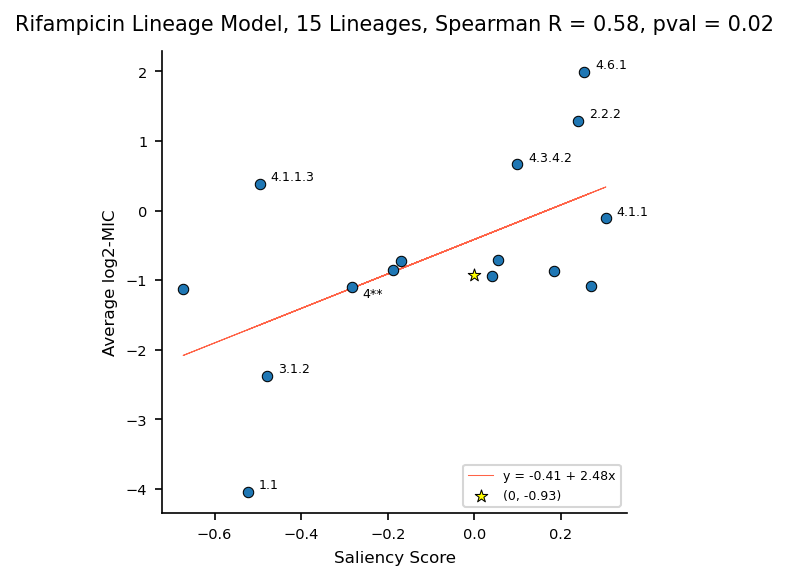

In [158]:
RIF_lineage_scores_df = generate_lineage_saliency_plot("Rifampicin",
                                                       "RIF", 
                                                       "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoBC_lineage", 
                                                       df_rif, 
                                                       binary_thresh=0.5,
                                                       sig_thresh=0.05,
                                                       significance=True,
                                                       binary=False, 
                                                       #savefName="../analysis/Rifampicin/lineage_scatter.png"
                                                     )

Mean MIC: 0.4293547943320952, Mean log2-MIC: -3.063541858435793
34/62 lineages are significant
16/34 saliency-significant lineages have average MICs significantly different from the mean
Predicted log2-MIC for saliency = 0: [-3.00153375]


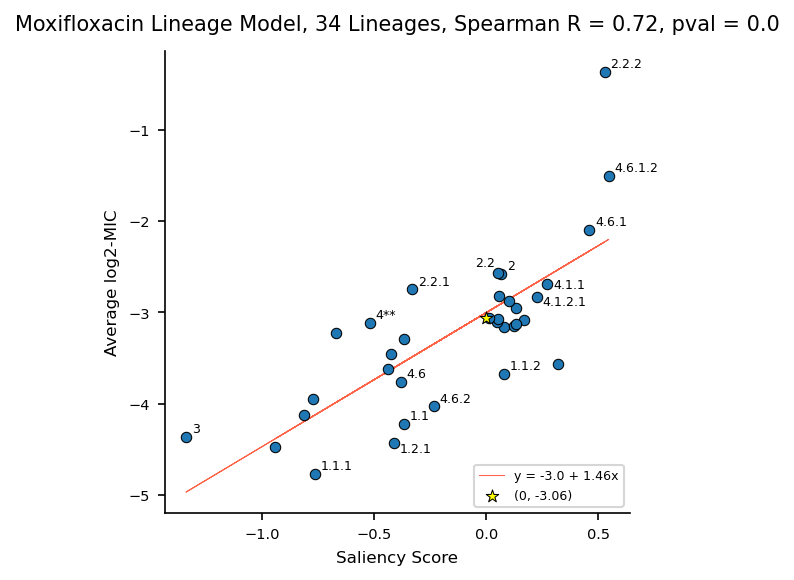

In [177]:
MXF_lineage_scores_df = generate_lineage_saliency_plot("Moxifloxacin",
                                                        "MXF", 
                                                      "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_gyrBA_lineage", 
                                                       df_mxf, 
                                                       binary_thresh=0.5,
                                                       sig_thresh=0.05,
                                                       significance=True,
                                                       binary=False, 
                                                       #savefName="../analysis/Moxifloxacin/lineage_scatter.png"
                                                     )

# MXF_lineage_scores_df = MXF_lineage_scores_df.merge(MXF_lineage_pred, on="Lineage")

# MXF_lineage_scores_df.loc[MXF_lineage_scores_df["Lineage"]=="H37Rv", "log2-MIC"] = np.log2(df_mxf["MXF_midpoint"].min())

In [184]:
RIF_lineage_pred = pd.read_csv("../analysis/Rifampicin/insilico_mutagenesis/lineage_predictions.csv")
MXF_lineage_pred = pd.read_csv("../analysis/Moxifloxacin/insilico_mutagenesis/lineage_predictions.csv")

In [187]:
np.exp2(RIF_lineage_pred.pred_log2_MIC.max())

0.08025914514426061

In [188]:
np.exp2(MXF_lineage_pred.pred_log2_MIC.max())

0.18891294906953887

In [227]:
st.spearmanr(lineage_pred_combined["RIF_pred_log2_MIC"], lineage_pred_combined["MXF_pred_log2_MIC"])

SignificanceResult(statistic=0.4002496159754224, pvalue=0.0011528652210491973)

<Axes: xlabel='MXF_pred_log2_MIC', ylabel='RIF_pred_log2_MIC'>

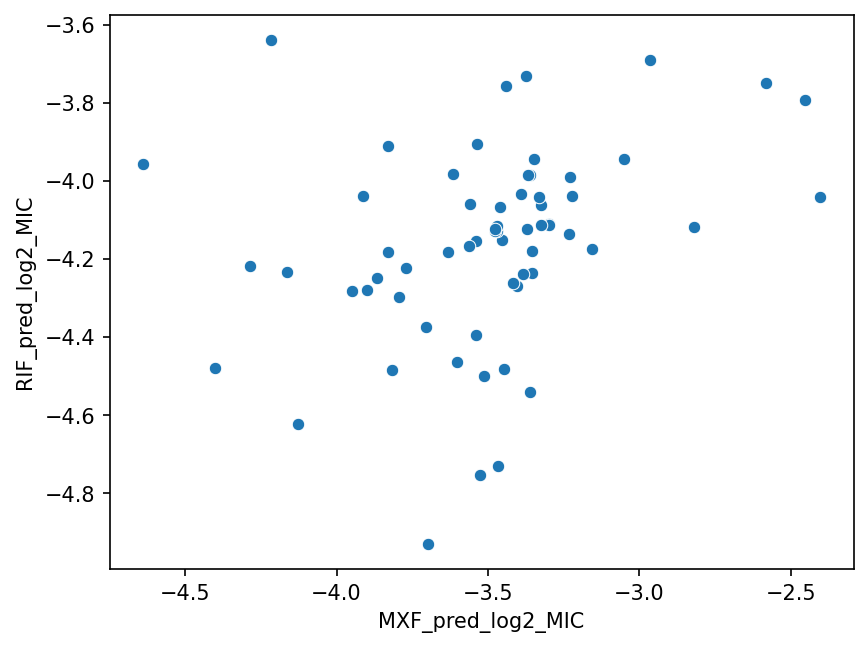

In [226]:
lineage_pred_combined = MXF_lineage_pred.rename(columns={"pred_log2_MIC": "MXF_pred_log2_MIC"}).merge(RIF_lineage_pred.rename(columns={"pred_log2_MIC": "RIF_pred_log2_MIC"}), on="Lineage")

sns.scatterplot(data=lineage_pred_combined,
                x="MXF_pred_log2_MIC",
                y="RIF_pred_log2_MIC"
               )

In [209]:


RIF_lineage_pred["Drug"] = "RIF"
MXF_lineage_pred["Drug"] = "MXF"

lineage_pred_combined = pd.concat([RIF_lineage_pred, MXF_lineage_pred], axis=0)

In [210]:
lineage_pred_combined

,Lineage,pred_log2_MIC,Drug
0,1.1.2,-3.639190,RIF
1,4.1.1,-3.689927,RIF
2,4.6.1.2,-3.731677,RIF
3,2.2.1.1,-3.749755,RIF
4,1.1.1.1,-3.757026,RIF
...,...,...,...
58,3.1.2.2,-4.164783,MXF
59,1.1.2,-4.217376,MXF
60,4.3.1,-4.285922,MXF
61,3.1.2.1,-4.401931,MXF


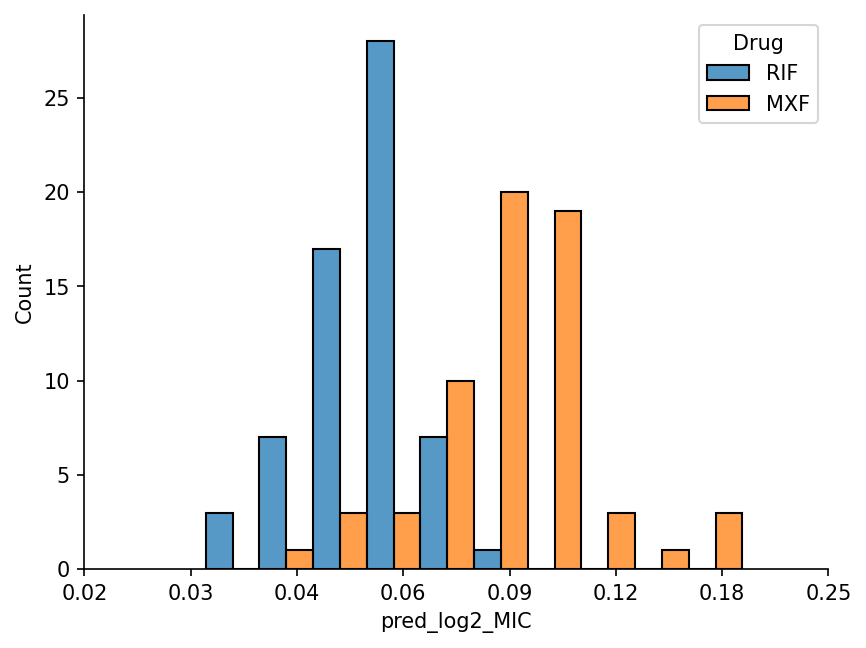

In [225]:
# sns.histplot(data=lineage_pred_combined,
#              x="RIF_pred_log2_MIC",
#              y="MXF_pred_log2_MIC"
#             )

fig, ax = plt.subplots()
sns.histplot(data=lineage_pred_combined,
             x="pred_log2_MIC",
             hue="Drug",
             multiple="dodge",
             common_bins=True
            )

ax.set_xticks(ticks=ax.get_xticks(), labels=np.round(np.exp2(ax.get_xticks()), 2))
sns.despine()
plt.show()

In [191]:
MXF_lineage_pred.sort_values("pred_log2_MIC", ascending=False)

,Lineage,pred_log2_MIC
0,1.1.3,-2.404206
1,2.2.2,-2.451891
2,2.2.1.1,-2.580526
3,4.2.2,-2.819749
4,4.1.1,-2.964838
...,...,...
58,3.1.2.2,-4.164783
59,1.1.2,-4.217376
60,4.3.1,-4.285922
61,3.1.2.1,-4.401931


In [67]:
MXF_lineage_scores_df.loc[(~pd.isnull(MXF_lineage_scores_df["log2-MIC"])) & (MXF_lineage_scores_df["Lineage"] != "H37Rv")].shape

(56, 14)

In [81]:
df_mxf["MXF_midpoint"].mean(), df_rif["RIF_midpoint"].mean()

(0.4293547943320952, 6.330409324723651)

In [79]:
np.log2(df_mxf["MXF_midpoint"].mean())

-1.219757793364881

In [80]:
np.mean(np.log2(df_mxf["MXF_midpoint"]))

-3.063541858435793

In [50]:
MXF_lineage_scores_df.query("Lineage.str.startswith('2')")

,position,Max,Min,Lineage,log2-MIC,MIC,MIC_pval,Max_pval,Min_pval,Bonferroni_Max_pval,Bonferroni_Min_pval,Bonferroni_MIC_pval,pred_log2_MIC,H37Rv_diff
2,346693,1.059132,0.000000,2.2.2,-0.368882,0.774382,7.589463e-43,0.0,NaN,0.0,NaN,4.250099e-41,-2.451891,1.024948
5,497491,0.134046,0.000000,2,-2.576839,0.167608,3.334114e-13,0.0,NaN,0.0,NaN,1.867104e-11,-3.354073,0.122766
12,797736,-0.000000,-0.331527,2.2.1,-2.747367,0.148922,1.293208e-05,NaN,0.0,NaN,0.0,7.241966e-04,-3.771430,-0.294591
29,1881090,-0.000000,-0.179701,2.1,-3.756470,0.073993,5.013278e-02,NaN,0.3,NaN,7.8,2.807436e+00,-3.467966,0.008873
32,2505085,0.101708,0.000000,2.2,-2.572242,0.168143,1.606959e-13,0.0,NaN,0.0,NaN,8.998972e-12,-3.330470,0.146369
46,3836274,-0.000000,-0.340768,2.2.1.2,-2.982621,0.126515,4.708863e-01,NaN,0.1,NaN,2.6,2.636963e+01,-3.299817,0.177022
53,4248115,-0.000000,-0.086942,2.2.1.1,-2.989912,0.125877,5.421119e-01,NaN,0.4,NaN,10.4,3.035827e+01,-2.580526,0.896313


In [64]:
st.spearmanr(MXF_lineage_scores_df.loc[~pd.isnull(MXF_lineage_scores_df["log2-MIC"])]["pred_log2_MIC"], 
             MXF_lineage_scores_df.loc[~pd.isnull(MXF_lineage_scores_df["log2-MIC"])]["log2-MIC"]
            )

SignificanceResult(statistic=0.3072453861927546, pvalue=0.02125752440344056)

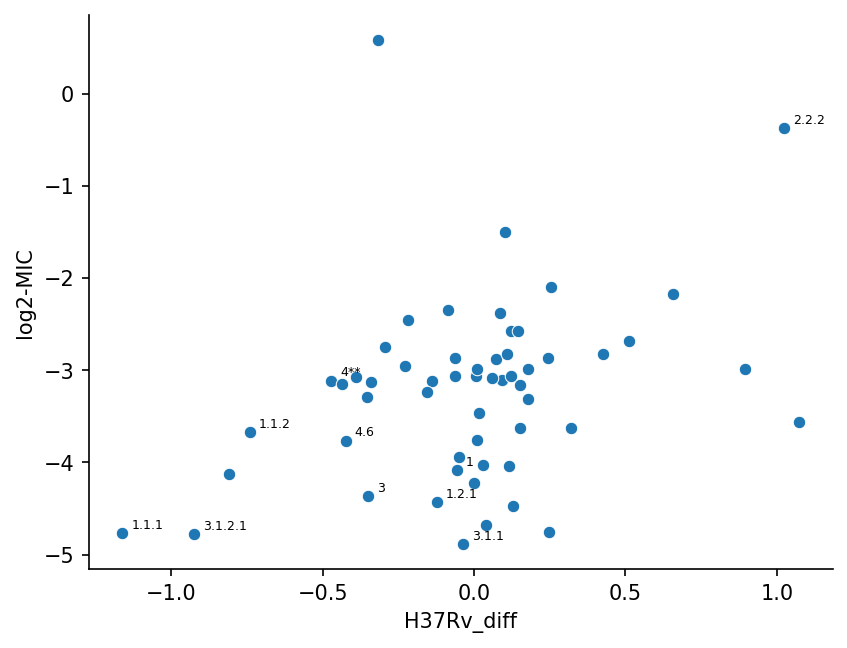

In [72]:
fig, ax = plt.subplots()

sns.scatterplot(data=MXF_lineage_scores_df,
                x="H37Rv_diff",
                y="log2-MIC",
                ax=ax
               )

label_thresh = 0
for i, row in MXF_lineage_scores_df.iterrows():
    if row["Bonferroni_MIC_pval"] < 0.05:
        if (row["log2-MIC"] > -1 and row["H37Rv_diff"] > 0) or (row["log2-MIC"] < -1 and row["H37Rv_diff"] < 0):
            ax.text(row["H37Rv_diff"] + 0.03, row["log2-MIC"] + 0.05, row["Lineage"], color='black', fontsize=6)

sns.despine()
plt.show()

In [39]:
MXF_lineage_scores_df.loc[MXF_lineage_scores_df["log2-MIC"] > -1]

,position,Max,Min,Lineage,log2-MIC,MIC_pval,Max_pval,Min_pval,Bonferroni_Max_pval,Bonferroni_Min_pval,Bonferroni_MIC_pval
2,346693,1.059132,0.0,2.2.2,-0.368882,7.589463e-43,0.0,NaN,0.0,NaN,4.250099e-41
44,3570528,0.131604,0.0,4.6.2.1,0.584963,7.852026e-02,0.2,NaN,6.0,NaN,4.397135e+00


In [9]:
MXF_lineage_scores_df.query("BH_MIC_enrich_pval < 0.05")

,position,Max,Min,Lineage,log2-MIC,MIC_enrich_pval,Max_pval,Min_pval,Bonferroni_Max_pval,Bonferroni_Min_pval,BH_MIC_enrich_pval,plot_score
1,346693,1.059132,0.000000,2.2.2,-0.368882,7.589463e-43,0.0,NaN,0.0,NaN,2.352733e-41,0.529566
5,615614,-0.000000,-0.816126,4.3.1,-4.124061,3.730382e-03,NaN,0.0,NaN,0.0,1.360492e-02,-0.816126
9,931123,-0.000000,-0.520368,4**,-3.112379,5.032185e-07,NaN,0.0,NaN,0.0,2.599962e-06,-0.520368
11,1455780,-0.000000,-0.942096,4.2.2.1,-4.473931,4.861285e-03,NaN,0.0,NaN,0.0,1.674443e-02,-0.942096
19,2622402,0.159957,0.000000,1.1.2,-3.670711,5.404333e-05,0.0,NaN,0.0,NaN,2.233791e-04,0.079978
21,3021283,-0.000000,-0.766567,1.1.1,-4.765267,1.546480e-29,NaN,0.0,NaN,0.0,3.196059e-28,-0.766567
22,3273107,-0.000000,-1.341570,3,-4.365256,3.066523e-80,NaN,0.0,NaN,0.0,1.901244e-78,-1.341570
23,3466426,-0.000000,-0.381547,4.6,-3.762887,2.331014e-06,NaN,0.0,NaN,0.0,1.111714e-05,-0.381547
24,3479545,-0.000000,-0.413427,1.2.1,-4.433936,9.712128e-06,NaN,0.0,NaN,0.0,4.301085e-05,-0.413427
27,4125058,-0.000000,-0.234043,4.6.2,-4.027618,1.643715e-09,NaN,0.0,NaN,0.0,1.019103e-08,-0.234043


In [25]:
thresh = 0.05/62

In [29]:
MXF_lineage_scores_df.query("MIC_enrich_pval < @thresh")

,position,Max,Min,Lineage,log2-MIC,MIC_enrich_pval,Max_pval,Min_pval,Bonferroni_Max_pval,Bonferroni_Min_pval,BH_MIC_enrich_pval,plot_score
1,346693,1.059132,0.000000,2.2.2,-0.368882,7.589463e-43,0.0,NaN,0.0,NaN,2.352733e-41,0.529566
9,931123,-0.000000,-0.520368,4**,-3.112379,5.032185e-07,NaN,0.0,NaN,0.0,2.599962e-06,-0.520368
19,2622402,0.159957,0.000000,1.1.2,-3.670711,5.404333e-05,0.0,NaN,0.0,NaN,2.233791e-04,0.079978
21,3021283,-0.000000,-0.766567,1.1.1,-4.765267,1.546480e-29,NaN,0.0,NaN,0.0,3.196059e-28,-0.766567
22,3273107,-0.000000,-1.341570,3,-4.365256,3.066523e-80,NaN,0.0,NaN,0.0,1.901244e-78,-1.341570
23,3466426,-0.000000,-0.381547,4.6,-3.762887,2.331014e-06,NaN,0.0,NaN,0.0,1.111714e-05,-0.381547
24,3479545,-0.000000,-0.413427,1.2.1,-4.433936,9.712128e-06,NaN,0.0,NaN,0.0,4.301085e-05,-0.413427
27,4125058,-0.000000,-0.234043,4.6.2,-4.027618,1.643715e-09,NaN,0.0,NaN,0.0,1.019103e-08,-0.234043
33,4404247,-0.000000,-0.366142,1.1,-4.223946,4.075474e-27,NaN,0.0,NaN,0.0,5.053588e-26,-0.366142


In [76]:
def generate_lineage_MIC_plot(drug, out_dir, df_phenos, insilico_pred_df, binary_thresh, binary=False, save_title=None):
    
    df_phenos["log2-MIC"] = np.log2(df_phenos[f"{drug}_midpoint"])
    min_mic = np.min((df_phenos[f"{drug}_midpoint"])
    
    # make lineage matrix. Do this before getting only the train or test set so that all lineages are there
    #lineages = get_lineages_matrix(df_phenos)
    lineages = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix_Coll2014.csv", index_col=[0])
    lineages.columns = lineages.columns.astype(int)
    assert len(np.unique(lineages.values)) == 2

    # get only the training or testing set and subset the lineage matrix too
    lineages = lineages.loc[df_phenos["ROLLINGDB_ID"]]
    
    if binary:
        saliency_dir = os.path.join(out_dir, "saliency/binary")
    else:
        saliency_dir = os.path.join(out_dir, "saliency/quant")
        
    # get lineage scores for the primary model
    lineage_scores = np.load(os.path.join(saliency_dir, "lineage_scores.npy"))
    
    # create a dataframe with lineages, scores, and average log-MIC of isolates
    lineage_scores_df = pd.DataFrame({"position": lineages.columns, 
                                      "Max": lineage_scores.max(axis=0), 
                                      "Min": lineage_scores.min(axis=0)
                                     })
    
    lineage_scores_df = lineage_scores_df.merge(coll_2014[["#lineage", "position"]], on="position")
    lineage_scores_df.rename(columns={"#lineage":"Lineage"}, inplace=True)
    lineage_scores_df["Lineage"] = [val.replace("lineage", "") for val in lineage_scores_df["Lineage"].values]
    
    # add log2-MIC to get averaged per lineage later
    lineages = lineages.merge(df_phenos[["ROLLINGDB_ID", "log2-MIC"]].set_index("ROLLINGDB_ID"), left_index=True, right_index=True)

    for i, row in lineage_scores_df.iterrows():

        # add average log2-MIC of isolates with that SNP
        log2_MIC = lineages.loc[lineages[row["position"]]==1]["log2-MIC"].mean()
        lineage_scores_df.loc[i, "log2-MIC"] =log2_MIC
    
        # then perform a hypothesis test for MIC enrichment (greater or less than the mean)
        pos, lineage = str(row["position"]), row["Lineage"]

        isolates_in_lineage = lineage_mat.loc[df_phenos["ROLLINGDB_ID"].values].loc[lineage_mat[pos]==1].index.values

        if len(isolates_in_lineage) > 0:

            if log2_MIC > np.log2(binary_thresh):
                alt = "greater"
            else:
                alt = "less"

            mu_stat, mu_pval = st.mannwhitneyu(df_phenos.query("ROLLINGDB_ID in @isolates_in_lineage")[f"{drug}_midpoint"].values, 
                                               df_phenos[f"{drug}_midpoint"].values,
                                               alternative=alt,
                                              )

            lineage_scores_df.loc[i, "MIC_enrich_pval"] = mu_pval
        
        else:
            lineage_scores_df.loc[i, "MIC_enrich_pval"] = np.nan

    
    lineage_scores_df_nonan = lineage_scores_df.loc[~pd.isnull(lineage_scores_df["MIC_enrich_pval"])]
    lineage_scores_df_nan = lineage_scores_df.loc[pd.isnull(lineage_scores_df["MIC_enrich_pval"])]
    
    _, mic_bh_pvals, _, _ = sm.multipletests(lineage_scores_df_nonan["MIC_enrich_pval"], method='fdr_bh', is_sorted=False, returnsorted=False)
    lineage_scores_df_nonan["BH_MIC_enrich_pval"] = mic_bh_pvals
    
    combined_df = pd.concat([lineage_scores_df_nonan, lineage_scores_df_nan], axis=0)
    
    # check that NaNs only occur when the lineage is not present in the dataset
    assert len(combined_df.loc[(~pd.isnull(combined_df["log2-MIC"])) & (pd.isnull(combined_df["BH_MIC_enrich_pval"]))]) == 0
    combined_df = combined_df.merge(insilico_pred_df, on="Lineage").reset_index(drop=True)
    combined_df = combined_df.dropna(axis=0).query("BH_MIC_enrich_pval < 0.05")
    combined_df["pred_log2_MIC_fold"] = combined_df["pred_log2_MIC"] / min_mic
    
    ######################################################## STEP 2: FIT A LINEAR REGRESSION ########################################################
    
    x_var = "pred_log2_MIC_fold"
    y_var = "log2-MIC"
    
    X = combined_df[x_var].values.reshape(-1, 1)
    y = combined_df[y_var]

    linReg = LinearRegression(fit_intercept=True)
    linReg.fit(X, y)
    yhat = linReg.predict(X)
    
    ######################################################## STEP 3: PLOT SCATTER PLOT WITH LINE AND SPEARMAN ########################################################

    fig, ax = plt.subplots()
    sns.scatterplot(data=combined_df, x=x_var, y=y_var, ax=ax, s=25)

    label_thresh = 0
    for i, row in combined_df.iterrows():

        if row["Max"] > label_thresh or row["Min"] < -label_thresh:
            
            # manual changes to prevent labels from covering each other up
            if row["Lineage"] == "BOV":
                ax.text(row[x_var] + 0.03, row[y_var] - 0.2, row["Lineage"], color='black', fontsize=6)
            elif row["Lineage"] == "1.1.1.1":
                ax.text(row[x_var] - 0.09, row[y_var] + 0.1, row["Lineage"], color='black', fontsize=6)
            else:
                ax.text(row[x_var] + 0.03, row[y_var] + 0.05, row["Lineage"], color='black', fontsize=6)

    plt.plot(np.squeeze(X), yhat, color="tomato", linewidth=0.5, label=f"y = {np.round(linReg.intercept_, 2)} + {np.round(linReg.coef_[0], 2)}x")

    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    
    plt.legend(fontsize=8, loc="lower right")
    plt.xlabel("\nInsilico Predicted log2-MIC", fontsize=9)
    plt.ylabel("Average log2-MIC\n", fontsize=9)
    sns.despine()
    
    spearman_results = st.spearmanr(np.squeeze(X), y)
    
    plt.title(f"{drug} Lineage Model, Spearman R = {np.round(spearman_results[0], 2)}", fontsize=10)
    
    # print(f"R^2: {linReg.score(X, y)}")
    print(f"Spearman pval: {spearman_results[1]}")
    
    if save_title is None:
        plt.show()
    else:
        plt.savefig(save_title, dpi=300)
    
    return combined_df

In [78]:
MXF_lineage_scores_df

,position,Max,Min,Lineage,log2-MIC,MIC_enrich_pval,BH_MIC_enrich_pval,pred_log2_MIC,pred_log2_MIC_fold
2,346693,1.009959,0.000000,2.2.2,-0.368882,7.589463e-43,2.125050e-41,-2.700629,0.445730
8,615614,-0.000000,-0.830255,4.3.1,-4.124061,3.730382e-03,1.228832e-02,-4.394011,0.725217
9,615938,-0.000000,-0.099820,1,-4.084534,6.266300e-29,8.772820e-28,-3.760959,0.620734
15,931123,-0.000000,-0.465243,4**,-3.112379,5.032185e-07,2.348353e-06,-4.072301,0.672120
16,1084911,-0.000000,-0.256978,3.1.1,-4.882956,1.073007e-10,7.511050e-10,-3.905972,0.644668
18,1237818,0.274216,0.000000,3.1.2.1,-4.774159,4.822896e-10,3.000913e-09,-4.401564,0.726463
19,1455780,-0.000000,-0.772527,4.2.2.1,-4.473931,4.861285e-03,1.512400e-02,-3.645515,0.601680
30,2622402,-0.000000,-0.026612,1.1.2,-3.670711,5.404333e-05,2.017618e-04,-4.289811,0.708019
32,2875883,-0.000000,-0.160979,4.6.2.2,-4.041740,3.582340e-08,1.823737e-07,-3.636657,0.600218
33,3021283,-0.000000,-0.577767,1.1.1,-4.765267,1.546480e-29,2.886763e-28,-4.627015,0.763673


Spearman pval: 0.2797642200565713


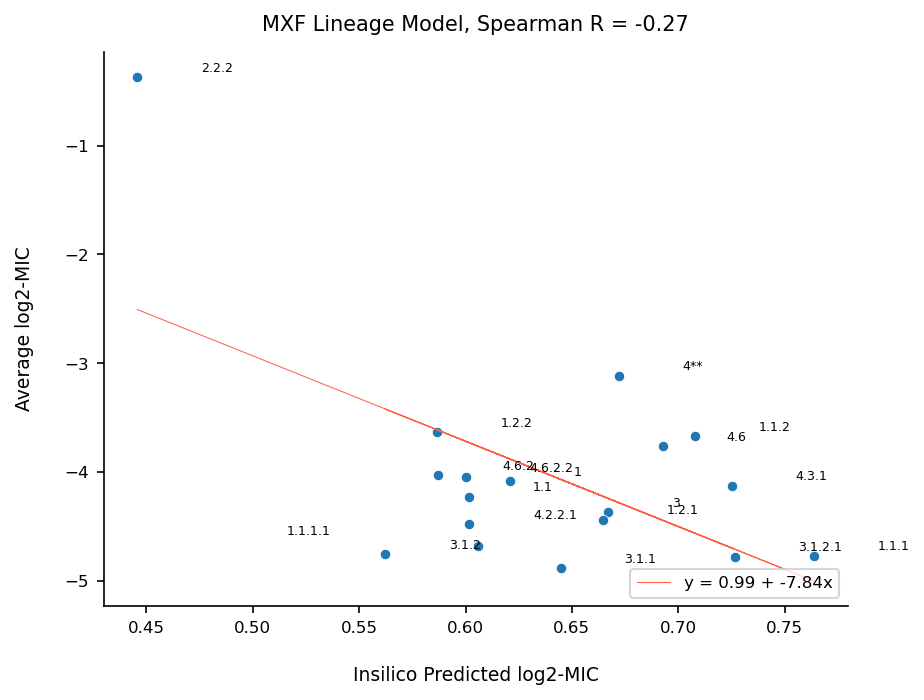

In [77]:
MXF_lineage_scores_df = generate_lineage_MIC_plot("MXF", 
                                                  "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_gyrBA_lineage", 
                                                  df_mxf, 
                                                  pd.read_csv("../analysis/Moxifloxacin/insilico_mutagenesis/lineage_predictions.csv"),
                                                  0.5,
                                                  binary=False, 
                                                  save_title=None
                                                 )

Spearman pval: 0.7093053657154911


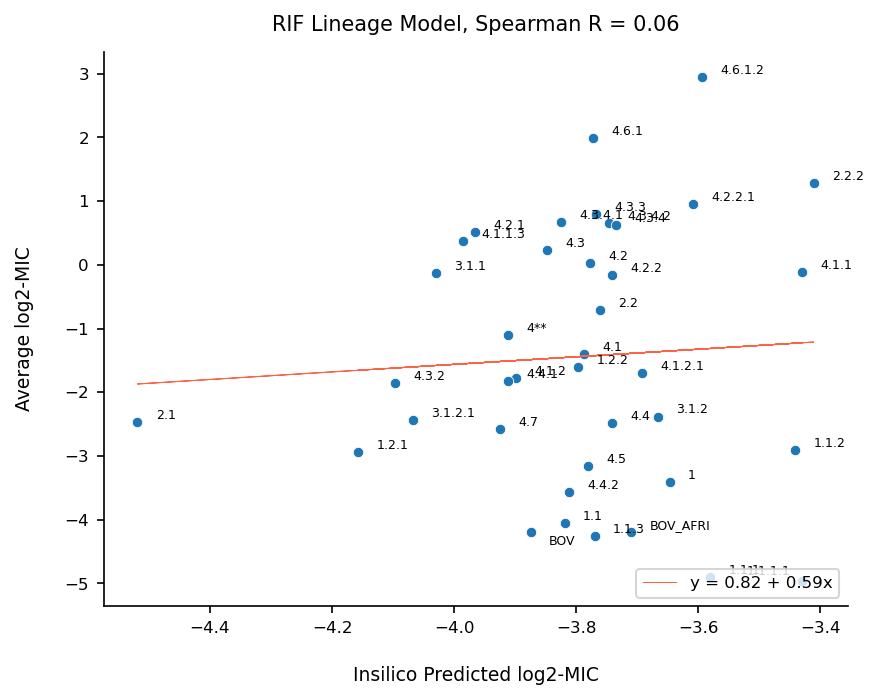

In [73]:
RIF_lineage_scores_df = generate_lineage_MIC_plot("RIF", 
                                                  "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoBC_lineage", 
                                                  df_rif, 
                                                  pd.read_csv("../analysis/Rifampicin/insilico_mutagenesis/lineage_predictions.csv"),
                                                  0.5,
                                                  binary=False, 
                                                  save_title=None
                                                 )

In [75]:
-3.4/(np.log2(0.015))

0.5611585504698132

57/62 lineages have a non-zero score
Spearman pval: 0.01933879630681962


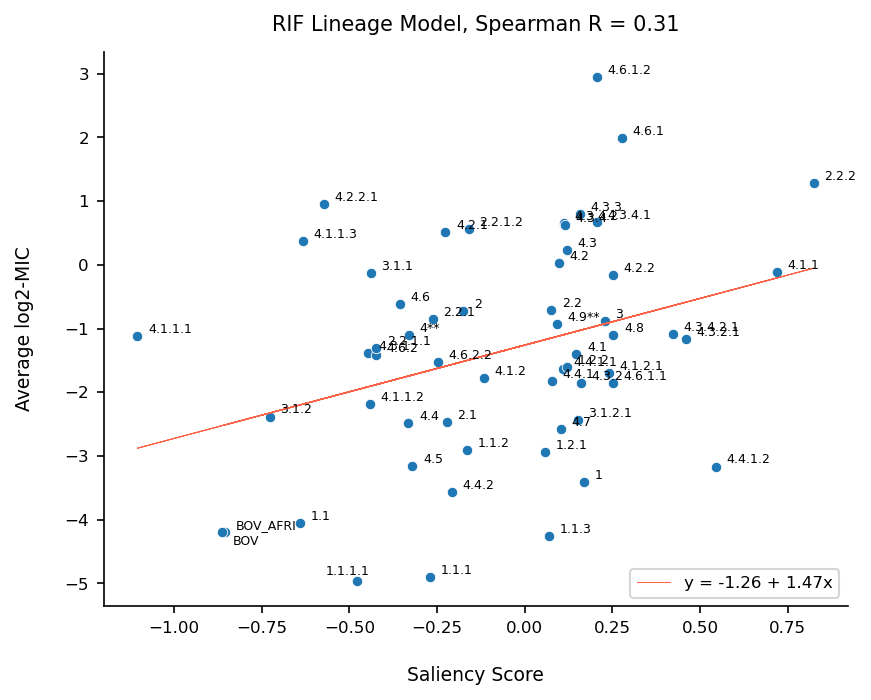

In [14]:
RIF_sig_lineage_scores = generate_lineage_saliency_plot("RIF", 
                                                       "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoBC_lineage", 
                                                       df_rif,
                                                       0.5,
                                                       significance=False,
                                                       #save_title="../analysis/Rifampicin/lineage_scatter.png"
                                                      )

56/62 lineages have a non-zero score
Spearman pval: 8.25294709646224e-06


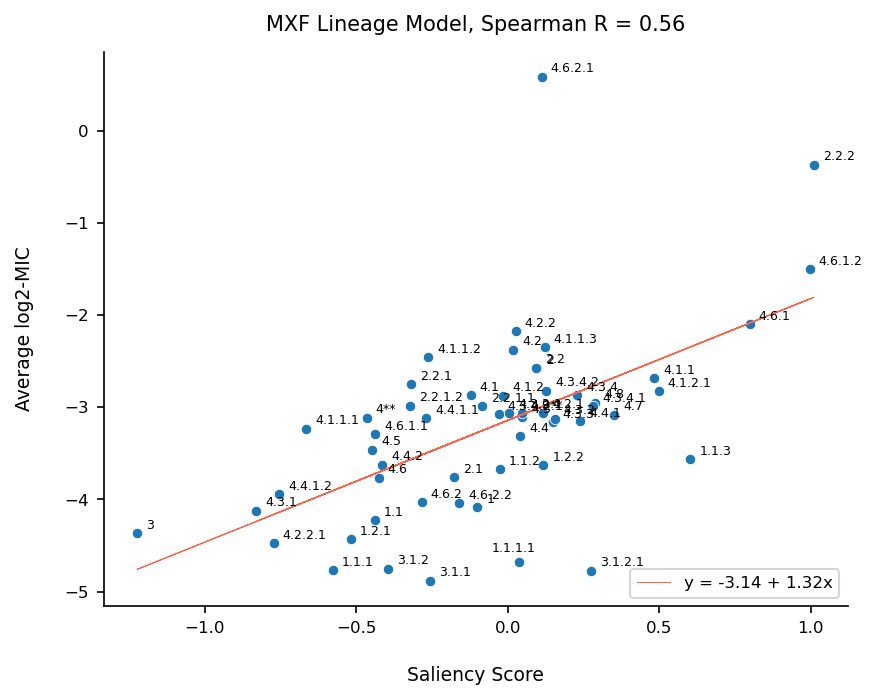

In [16]:
MXF_sig_lineage_scores = generate_lineage_saliency_plot("MXF", 
                                                       "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_gyrBA_lineage", 
                                                       df_mxf,
                                                       0.5,
                                                       significance=False,
                                                       #save_title="../analysis/Rifampicin/lineage_scatter.png"
                                                      )

In [10]:
# MXF_sig_lineage_scores_df = generate_lineage_saliency_plot("MXF", 
#                                                            "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_gyrBA_lineage", 
#                                                            df_mxf,
#                                                            0.5,
#                                                            sig_thresh=0.5,
#                                                            significance=True,
#                                                            #save_title="../analysis/Rifampicin/lineage_scatter.png"
#                                                           )

# Is MIC Significantly Elevated in Certain Lineages

In [299]:
RIF_sig_lineage_scores_df.query("Lineage in ['4.2.1', '2.2.1']")

,position,Max,Min,Lineage,Max_pval,Min_pval,BH_Max_pval,BH_Min_pval,log2-MIC,MIC_enrich_pval,BH_MIC_enrich_pval,plot_score
3,783601,-0.0,-0.393883,4.2.1,0.1,0.0,0.344444,0.0,0.510582,0.000498,0.001029,-0.393883
4,797736,-0.0,-0.223559,2.2.1,0.4,0.0,0.590476,0.0,-0.853869,0.457839,0.535586,-0.223559


In [287]:
RIF_sig_lineage_scores_df.query("BH_MIC_enrich_pval < 0.05")

,position,Max,Min,Lineage,Max_pval,Min_pval,BH_Max_pval,BH_Min_pval,log2-MIC,MIC_enrich_pval,BH_MIC_enrich_pval,plot_score
1,346693,0.741299,0.000000,2.2.2,0.0,0.6,0.000000,0.676364,1.292509,6.141254e-16,4.759472e-15,0.741299
2,514245,0.691994,0.000000,4.1.1,0.0,0.6,0.000000,0.676364,-0.111073,8.549601e-06,2.304675e-05,0.691994
6,1882180,-0.000000,-0.669186,BOV_AFRI,0.6,0.0,0.641379,0.000000,-4.199761,5.087022e-06,1.470124e-05,-0.669186
7,2831482,-0.000000,-0.655679,BOV,0.6,0.0,0.641379,0.000000,-4.199761,5.087022e-06,1.470124e-05,-0.655679
8,3021283,-0.000000,-0.317414,1.1.1,0.3,0.0,0.581250,0.000000,-4.897060,2.157014e-53,4.457829e-52,-0.317414
9,3216553,-0.000000,-0.364554,1.1.1.1,0.5,0.0,0.620000,0.000000,-4.959214,9.729504e-46,1.508073e-44,-0.364554
12,4260268,0.444209,0.000000,4.6.1,0.0,0.9,0.000000,0.914754,1.988988,1.512227e-06,5.515181e-06,0.444209
13,4404247,-0.000000,-0.363112,1.1,0.5,0.0,0.620000,0.000000,-4.045164,1.138472e-65,7.058529e-64,-0.363112


In [ ]:
# nice! does not co-occur with canonical gyrBA mutations
plot_variant_mics("gyrBA", 7566, moxi_gyrBA_seq_dict, df_moxi, isolates_with_gyrBA_mut, title="../Figures/gyrBA_7566_mic_dist.png")

In [ ]:
# too few isolates: only 5 with gyrBA or the variant at all. Also not convincing with the shift
# plot_variant_mics("gyrBA", 7521, moxi_gyrBA_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
# not super convincing. 22 total isolates, but gyrBA variants seem to be higher
# 6735, 6737, 6749
plot_variant_mics("gyrBA", 6735, moxi_gyrBA_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
plot_variant_mics("gyrBA", 8164, moxi_gyrBA_seq_dict, df_moxi, isolates_with_gyrBA_mut, title="../Figures/gyrBA_8164_mic_dist.png")

# Moxifloxacin Multiloci Models

In [ ]:
# moxi_gyrBA_6Loci_df, moxi_gyrBA_6Loci_seq_dict = generate_saliency_plots("config_moxi_6Loci.yaml",
#                                                              ["MXF"],
#                                                              cat_to_check=["1", "2"],
#                                                              binary=False,
#                                                              isolate_variants_df=None,
#                                                              num_bootstrap=1, 
#                                                              save=True
#                                                             )

# Bedaquiline

In [ ]:
# bdq_no_lineage_df, bdq_no_lineage_seq_dict = generate_saliency_plots("config_bdq_old.yaml",
#                                                              ["BDQ"],
#                                                              cat_to_check=["1", "2"],
#                                                              binary=False,
#                                                              isolate_variants_df=None,
#                                                              num_bootstrap=1, 
#                                                              save=True
#                                                             )

# Rifampicin

In [ ]:
rif_rpoBC_df, rif_rpoBC_seq_dict = generate_saliency_plots("config_rif.yaml",
                                                             ["RIF"],
                                                             cat_to_check=["1", "2"],
                                                             binary=False,
                                                             isolate_variants_df=None,
                                                             num_bootstrap=1000, 
                                                             save=True
                                                            )

In [ ]:
who_single_drug = who_variants.query("drug=='RIF'")

who_pos = who_single_drug["genome_index"].str.split(",", expand=True)
who_pos.columns = ["pos1", "pos2"]

who_single_drug = pd.concat([who_single_drug, who_pos], axis=1).reset_index(drop=True)
print(who_single_drug.shape)

In [ ]:
for i, row in who_single_drug.iterrows():
    
    if not pd.isnull(row["pos2"]):
        
        # duplicate the row and make pos1 to pos2 in the duplicate
        add_row = who_single_drug.iloc[i, :]
        add_row["pos1"] = row["pos2"]
        
        who_single_drug = pd.concat([who_single_drug, pd.DataFrame(add_row).T], axis=0)
        
who_single_drug = who_single_drug.reset_index(drop=True)
del who_single_drug["pos2"]
del who_single_drug["genome_index"]
print(who_single_drug.shape)
who_single_drug.rename(columns={"pos1": "Pos"}, inplace=True)
who_single_drug["Pos"] = who_single_drug["Pos"].astype(float).astype(object)

In [ ]:
# get all sites with positive saliency scores
rif_resistance_analysis = rif_rpoBC_df.query("Max > 0 & max_pVal < 0.05").merge(who_single_drug, on="Pos", how="outer").sort_values("Max", ascending=False)

rif_resistance_analysis = rif_resistance_analysis.query("gene in ['rpoB', 'rpoC']").reset_index(drop=True)

del rif_resistance_analysis["Unnamed: 0"]
print(rif_resistance_analysis.shape)

#new_pos = rif_resistance_analysis.query("confidence in ['3) Uncertain significance', '5) Not assoc w R']")
new_pos = rif_resistance_analysis.loc[(~pd.isnull(rif_resistance_analysis["Max"])) & (rif_resistance_analysis["confidence"] == '3) Uncertain significance')]

print(new_pos.shape)

In [ ]:
for i, row in new_pos.iterrows():
    
    ref = rif_rpoBC_seq_dict["rpoBC"].loc["MT_H37Rv", row["Pos"]]
    alt = rif_rpoBC_seq_dict["rpoBC"][row["Pos"]] != ref
    new_pos.loc[i, "Num_Isolates"] = sum(alt)
    
# new_pos = new_pos.query("Num_Isolates > 5").reset_index(drop=True)
new_pos["Num_Isolates"] = new_pos["Num_Isolates"].astype(int) 
print(new_pos.shape)

In [ ]:
new_pos.sort_values(["Num_Isolates", "Max"], ascending=False)

In [ ]:
drug = "RIF"
locus = "rpoBC"
pos = 761880.0
cc = 0.5

for _, row in new_pos.drop_duplicates("Pos").sort_values(["Num_Isolates", "Max"], ascending=False).iterrows():
    plot_variant_mics(drug, locus, row["Pos"], rif_rpoBC_seq_dict, df_rif, isolates_with_rpoBC_mut, cc, title=None)

In [ ]:
# rif_rpoABC_df, rif_rpoABC_seq_dict = generate_saliency_plots("config_rif_multiLoci.yaml",
#                                                              ["RIF"],
#                                                              cat_to_check=["1", "2"],
#                                                              binary=False,
#                                                              isolate_variants_df=None,
#                                                              num_bootstrap=1, 
#                                                              save=True
#                                                             )

In [ ]:
# drug = "RIF"
# locus = "rpoA"
# pos = 3878575.0
# cc = 0.5

# plot_variant_mics(drug, locus, pos, rif_rpoABC_seq_dict, df_rif, isolates_with_rpoBC_mut, cc, title=None)

In [ ]:
# rif_rpoABC_Rv2752c_df, rif_rpoABC_Rv2752c_seq_dict = generate_saliency_plots("config_rif.yaml",
#                                                                              ["RIF"],
#                                                                              cat_to_check=["1", "2"],
#                                                                              binary=False,
#                                                                              isolate_variants_df=None,
#                                                                              num_bootstrap=1, 
#                                                                              save=True
#                                                                             )

In [ ]:
# rif_rpoBC_lineage_df, rif_rpoBC_lineage_seq_dict = generate_saliency_plots("config_rif_lineage.yaml",
#                                                              ["RIF"],
#                                                              cat_to_check=["1", "2"],
#                                                              binary=False,
#                                                              isolate_variants_df=None,
#                                                              num_bootstrap=1, 
#                                                              save=True
#                                                             )

In [ ]:
def two_sample_mean_bootstrap(variant_mics, no_variant_mics, num_bootstrap=1000):
    '''
    Want log2(fold change) > 1. 
    '''
    
    if len(variant_mics) > 0 and len(no_variant_mics) > 0:
        bs_res = []
        #test_stat = np.mean(variant_mics) - np.mean(no_variant_mics)
        test_stat = np.log2(np.mean(variant_mics) / np.mean(no_variant_mics))

        # do bootstrapping of difference in means. Randomly sample isolates from the two groups, then compute the mean difference in MIC between them
        for _ in range(num_bootstrap):

            # draw bootstraps
            variant_sample = np.random.choice(variant_mics, np.max([len(variant_mics), num_bootstrap]), replace=True)
            no_variant_sample = np.random.choice(no_variant_mics, np.max([len(no_variant_mics), num_bootstrap]), replace=True)

            # get the test statistic and add it to a running list
            #stat = np.mean(variant_sample) - np.mean(no_variant_sample)
            stat = np.log2(np.mean(variant_sample) / np.mean(no_variant_sample))
            bs_res.append(stat)
    else:
        test_stat = np.nan
        bs_res = np.ones(num_bootstrap) * np.nan
        
    return test_stat, np.array(bs_res)

In [ ]:
def plot_variant_mics(drug, locus, variant, mat_seq_dict, df_phenos, isolates_with_canonical_mut, cc, title=None):
    
    # sns.color_palette("Set2").as_hex()[0]
    palette = "Set1"
    color_dict = {"no variants": sns.color_palette(palette).as_hex()[-1], 
                  "variant only": sns.color_palette(palette).as_hex()[1],
                  "canonical mut only": sns.color_palette(palette).as_hex()[4],
                  "canonical mut + variant": sns.color_palette(palette).as_hex()[0]
                 }
        
    ref = mat_seq_dict[locus].loc["MT_H37Rv", variant]
    isolates_with_variant = mat_seq_dict[locus].loc[mat_seq_dict[locus][variant] != ref, variant].index.values
    
    isolates_both = list(set(isolates_with_canonical_mut).intersection(isolates_with_variant))
    isolates_variant_only = list(set(isolates_with_variant) - set(isolates_with_canonical_mut))
    isolates_canonical_only = list(set(isolates_with_canonical_mut) - set(isolates_with_variant))
    
    isolates_nothing_1 = list(set(df_phenos["ROLLINGDB_ID"]) - set(isolates_both) - set(isolates_variant_only) - set(isolates_canonical_only))
    isolates_nothing_2 = list(set(df_phenos["ROLLINGDB_ID"]) - set(isolates_with_canonical_mut) - set(isolates_with_variant))
    assert len(isolates_nothing_1) == len(isolates_nothing_2) == len(set(isolates_nothing_1).intersection(isolates_nothing_2))
        
    df_phenos.loc[df_phenos["ROLLINGDB_ID"].isin(isolates_nothing_1), "Variant"] = 'no variants'
    df_phenos.loc[df_phenos["ROLLINGDB_ID"].isin(isolates_both), "Variant"] = 'canonical mut + variant'
    df_phenos.loc[df_phenos["ROLLINGDB_ID"].isin(isolates_variant_only), "Variant"] = 'variant only'
    df_phenos.loc[df_phenos["ROLLINGDB_ID"].isin(isolates_canonical_only), "Variant"] = 'canonical mut only'
                            
    # print("There are no isolates without canonical variants, but with the variant of interest")
    if ~('variant only' not in df_phenos["Variant"].value_counts().index.values):
        df_phenos["log-MIC"] = np.log(df_phenos[f"{drug}_midpoint"])
        if (len(df_phenos.query("Variant == 'variant only'")) > 0) & (len(df_phenos.loc[(df_phenos["Variant"] == 'variant only') & (df_phenos[f"{drug}_midpoint"] > cc)]) > 1):
            print(df_phenos.groupby("Variant")[f"{drug}_midpoint"].mean())
            print(df_phenos["Variant"].value_counts())

            fig, ax = plt.subplots(1, 1, figsize=(12, 4))
            g = sns.histplot(data=df_phenos, x="log-MIC", hue='Variant', 
                             stat='probability', common_norm=False, multiple='dodge', 
                             hue_order=["no variants", 'canonical mut only', "variant only", 'canonical mut + variant'], 
                             palette=color_dict, ax=ax)

            plt.xlabel("MIC (μg/mL)")
            plt.xticks(ticks=ax.get_xticks(), labels=np.round(np.exp(ax.get_xticks()), 2).astype(str))
            ax.set_title(f"{drug} MIC Distribution for Variants at Position {int(variant)}")

            sns.move_legend(ax, "upper left", title=None)
            sns.despine()

            if title is None:
                plt.show()
            else:
                plt.savefig(title, dpi=300)
        # else:
        #     print(f"There are no isolates with only a variant at {variant}")

In [ ]:
def filter_saliencies(saliency_df, mat_seq_dict, drug, df_phenos):
    
    # get positions with non-zero scores
    nonZero = saliency_df.query("Max != 0 | Min != 0")
    
    # find the number of isolates with 
    for i, row in nonZero.iterrows():
        df = mat_seq_dict[row["Gene"]]
        if len(df[row["Pos"]].unique()) > 1:
            nonZero.loc[i, "Variant"] = 1
        else:
            nonZero.loc[i, "Variant"] = 0

    nonZero_analysis = nonZero.query("Variant == 1").sort_values("Max", ascending=False)
    
    for i, row in nonZero_analysis.iterrows():

        gene = row["Gene"]
        pos = row["Pos"]
        ref = mat_seq_dict[gene].loc["MT_H37Rv", pos]

        isolates_with_variant = mat_seq_dict[gene].loc[mat_seq_dict[gene][pos] != ref, pos].index.values

        if len(isolates_with_variant) >= 5:
            phenos_variant = df_phenos.query("ROLLINGDB_ID in @isolates_with_variant")[f"{drug}_midpoint"].values
            phenos_no_variant = df_phenos.query("ROLLINGDB_ID not in @isolates_with_variant")[f"{drug}_midpoint"].values

            stat, bootstrap_reps = two_sample_mean_bootstrap(phenos_variant, phenos_no_variant, num_bootstrap=100)
            lower, upper = np.percentile(bootstrap_reps, q=[2.5, 97.5])

            nonZero_analysis.loc[i, ["log2_FC", "log2_FC_LB", "log2_FC_UB"]] = stat, lower, upper
        else:
            nonZero_analysis.loc[i, ["log2_FC", "log2_FC_LB", "log2_FC_UB"]] = np.nan, np.nan, np.nan
            
    return nonZero_analysis.dropna(axis=0, how="any")

In [ ]:
df_moxi.query("gyrBA_mut==0").to_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/20220929_no_gyrBACanonicalMut.csv", index=False)

In [ ]:
test = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/20220929_no_gyrBACanonicalMut.csv")

In [ ]:
test.shape

In [ ]:
4819/(4819+1198)

In [ ]:
1198/(4819+1198)

In [ ]:
df_moxi.query("gyrBA_mut==0").groupby("category")["MOXI_midpoint"].mean()

In [ ]:
df_moxi.query("ROLLINGDB_ID not in @isolates_with_gyrBA_mut").MOXI_midpoint.max()

In [ ]:
df_moxi.query("ROLLINGDB_ID in @isolates_with_gyrBA_mut").MOXI_midpoint.max()

In [ ]:
#plot_variant_mics("Rv3361c_Rv3365c", 3774261, moxi_4Loci_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
#plot_variant_mics("Rv3561_Rv3565", 4005357.0, moxi_4Loci_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
#plot_variant_mics("Rv3561_Rv3565", 4004893.0, moxi_4Loci_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
moxi_isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/isolate_variants.csv")

# Moxifloxacin Multi-Loci

In [ ]:
locus_list = ['gyrBA', 'Rv0981_Rv0984', 'Rv3361c_Rv3365c', 'Rv3561_Rv3565'] 
moxi_4loci_df, moxi_4Loci_seq_dict = generate_saliency_plots("MOXI", 
                                                                 locus_list, 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/20220928_moxi_4Loci", 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/fastas", 
                                                                 ["MXF"], 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/20220902_data_clean.csv",
                                                                 cat_to_check=["1", "2"],
                                                                 isolate_variants_df=None,
                                                                 num_bootstrap=1000, 
                                                                 save=False
                                                                )

In [ ]:
locus_list = ['gyrBA', 'Rv0981_Rv0984', 'Rv2836c_Rv2837c', 'Rv3361c_Rv3365c', 'Rv0014c_Rv0015c', 'arfABC', 'phoPR', 'mbtK', 'Rv3561_Rv3565', 'stp', 'Rv0053_Rv0058', 'ligD_Rv0939'] 
# definitely remove: phoPR, stp, mbtK, Rv2836c_Rv2837c (dinF)
# next tier: arfABC, Rv0014c_Rv0015c

# generally good agreement between low saliency and not much contribution to MAE reduction

moxi_12loci_df, moxi_12Loci_seq_dict = generate_saliency_plots("MOXI", 
                                                                 locus_list, 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/20220907_moxi_12Loci", 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/fastas", 
                                                                 ["MXF"], 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/20220902_data_clean.csv",
                                                                 cat_to_check=["1", "2"],
                                                                 isolate_variants_df=None,
                                                                 num_bootstrap=1000, 
                                                                 save=False
                                                                )

# Analysis of Positions from Multi-Gene Model

In [ ]:
def validate_with_MIC_dist(locus, variant_col, mat_seq_dict, df_phenos, isolates_with_gyrBA_mut, num_bootstrap=1000):
    
    # check for significantly positive confidence intervals for all 3 groups -- isolates with canonical gyrBA mutations, isolates without, and all isolates
    ci_no_gyrBA, ci_gyrBA = plot_variant_mics(locus, variant_col, mat_seq_dict, df_phenos, isolates_with_gyrBA_mut, num_bootstrap=num_bootstrap, plot=False)
    #ci_all = plot_variant_mics_full_dist(locus, variant_col, mat_seq_dict, df_phenos, plot=False)
    
    # if at least one of them is significantly positive, keep that variant    
    cis_lst = [ci_no_gyrBA, ci_gyrBA]
    
    sig_bool = False
    for ci in cis_lst:
        
        if ci[0] > 0 and ci[1] > 0:
            sig_bool = True
            break
            
    if sig_bool:
        return 1
    else:
        return 0

In [ ]:
def filter_saliencies_by_seq_quality(var, gene, seq_dict, isolate_variants_df):
    
    ref_allele = seq_dict[gene].loc["MT_H37Rv", var]
    alt_alleles = seq_dict[gene].loc[seq_dict[gene][var] != ref_allele, var].unique()
    
    if type(var) in [float, int]:
        print("Pos found")
        # more than half of the variants must have passed QC
        if isolate_variants_df.query("POS == @var").QC.fillna(0).mean() > 0.5:
            # print(isolate_variants_df.query("POS == @var").QC.value_counts())
            print(isolate_variants_df.query("POS == @var").Isolate.unique())
        
    elif var.isnumeric():
        print("Pos found")
        print(isolate_variants_df.query("POS == @var").Isolate.unique())
        
    # insertion relative to H37Rv
    else:  
        if ref_allele == '-':
            var_pos = np.where(seq_dict[gene].columns == var)[0][0]
            prev_pos = seq_dict[gene].columns[var_pos-1]
            
            if isolate_variants_df.query("POS == @prev_pos").QC.fillna(0).mean() > 0.5:
                # print(isolate_variants_df.query("POS == @var").QC.value_counts())
                print(isolate_variants_df.query("POS == @prev_pos").Isolate.unique())

## The next 2 cells aren't needed because they don't significantly improve interpretation of results

In [ ]:
# # Merging promoters for plus strand
# promoter_location_data1 = pd.read_csv("../inputs/promoters_plus_strand.csv")
# data = promoter_location_data1.sort_values("upstream")[["downstream_gene", "position_upstream", "site", "upstream", "downstream"]]
# output_data =  []
# tracked_row = list(data.iterrows())[0][1]
# current_end = 74

# for idx, row in data.iterrows():

#     if row.upstream <= current_end:
#         # merging triggered
#         current_end = row.downstream
#     else:
#         tracked_row["downstream"] = current_end
#         output_data.append(tracked_row)
#         tracked_row = row
#         current_end = row.downstream
        
# output_data = pd.DataFrame(output_data)  
# output_data = output_data.iloc[1::,]
# print(len(data), len(output_data))
# promoter_location_data1= output_data

# # Merging promoters for minus strand
# promoter_location_data2 = pd.read_csv("../inputs/promoters_minus_strand.csv")
# data = promoter_location_data2.sort_values("upstream")[["downstream_gene", "position_upstream", "site", "upstream", "downstream"]]
# data = data.rename({
#     "upstream": "downstream",
#     "downstream": "upstream"
# }, axis = 1)
# output_data =  []
# tracked_row = list(data.iterrows())[0][1]
# current_end = 0

# for idx, row in data.iterrows():

#     if row.upstream <= current_end:
#         # merging triggered
#         current_end = row.downstream
#     else:
#         tracked_row["downstream"] = current_end
#         output_data.append(tracked_row)
#         tracked_row = row
#         current_end = row.downstream
        
# output_data = pd.DataFrame(output_data)  
# output_data = output_data.iloc[1::,]
# output_data = output_data.rename({
#     "upstream": "downstream",
#     "downstream": "upstream"
# }, axis = 1)
# print(len(data), len(output_data))
# promoter_location_data2= output_data

In [ ]:
# Add promoter annotations to genome
# H37Rv Genome

# for idx,row in promoter_location_data1.iterrows():
#     #Plus strand promoters
#     annotate_biopython_record(record, location=(
#         row.upstream, row.downstream, 1
#     ), feature_type="promoter")
    
# for idx,row in promoter_location_data2.iterrows():
#     #Plus strand promoters
#     annotate_biopython_record(record, location=(
#         row.downstream, row.upstream, -1
#     ), feature_type="promoter")